## Libraries

In [4]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    `cudnn.benchmark = False` can cost a bit of throughput - autotuning
    normally picks the fastest kernel for the input shape - an acceptable
    trade for bit-reproducible runs. Determinism is only guaranteed on the
    SAME machine / CUDA / torch version - it is not portable across hardware
    or library versions.

    NOTE: this notebook's training loop batches by indexing GPU-resident
    tensors directly (torch.randperm for shuffling) rather than a
    DataLoader/TensorDataset - there's no multiprocess data-loading worker
    to seed separately, so set_seed()'s torch.manual_seed/cuda.manual_seed_all
    already covers the shuffling order.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ---------------------------------------------------------------------------
# Paths - 1 lepton + 2 taus, Run 2 and Run 3 (same source files as
# Final_Notebooks/1L2Tau_Master_Pipeline.ipynb, so the AUC is directly
# comparable to the XGBoost baseline).
# ---------------------------------------------------------------------------

BASE_DIR_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_RUN3 = Path("PPSSP_2026/1l2tau/run3")

# Active run used by downstream cells by default.
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselection (see repo README.md, "1 Lepton 2 Taus")
# ---------------------------------------------------------------------------

PRESELECTION = "(n_b_jet == 0) & (n_jet >= 2)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background)
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy (identical to the XGBoost master
# pipeline, so the two models see the same information).
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]
BLOCK_EXACT = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig", "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode", "tau1_nprong", "tau2_nprong"
}

BLOCK_EXACT_LOWER = {b.lower() for b in BLOCK_EXACT}


def is_feature(branch: str) -> bool:

    """True if `branch` is safe to use as a training feature (see policy above)."""

    lb = branch.lower()
    return lb not in BLOCK_EXACT_LOWER and not any(s.lower() in lb for s in BLOCK_SUBSTR)

## Data Loading Helpers

In [6]:
def discover_common_features(base_dir, files=FILES, tree_name=TREE_NAME):
    
    """
    Branches common to EVERY process file in `base_dir`, filtered through`is_feature`.
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, files=FILES, weight_parts=WEIGHT_PARTS,
                   preselection=PRESELECTION, tree_name=TREE_NAME, verbose=True):

    """
    Read every process file under `base_dir`, apply the preselection at
    read time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts, cut=preselection, library="pd")
        df["w_phys"] =  df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)
    
    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features

## Load Run 2 and Run 3 Data (Shared Setup)

In [7]:
# Run 2 load

candidate_features_run2 = discover_common_features(BASE_DIR_RUN2)
data_run2 = load_run_data(BASE_DIR_RUN2, candidate_features_run2)
data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)

# Run 3 load (prepared now; used later in a separate downstream section)

candidate_features_run3 = discover_common_features(BASE_DIR_RUN3)
data_run3 = load_run_data(BASE_DIR_RUN3, candidate_features_run3)
data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

# Default active dataset for downstream cells in this first pass: Run 2.

candidate_features, data, features = candidate_features_run2, data_run2, features_run2
BASE_DIR = BASE_DIR_RUN2
ACTIVE_RUN = "Run 2"

print(f"Prepared datasets: Run2={len(data_run2)} events, Run3={len(data_run3)} events")
print(f"Downstream now uses: {ACTIVE_RUN}")

81 candidate features (common to all 10 processes, leakage-free)


signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29
81 candidate features (common to all 10 processes, leakage-free)
signal_ggF 

## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [8]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the Task-2 missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 64 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.474042                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing

Deterministic two-stage stratified **80/10/10** train/val/test split
(`make_3way_split`) - IDENTICAL logic/seed to
`1L2Tau_Master_Pipeline.ipynb`'s `make_3way_split`, so both notebooks land on
byte-identical partitions. **TEST is held out**: it does not participate in
the median imputation, the `StandardScaler` fit, the `flag_cols` definition,
early stopping, or the significance-scan score-cut selection below - it is
only read once, in the "Held-Out Test Evaluation" cell at the end of this
section, and its partition is persisted to disk and cross-checked against
`1L2Tau_Master_Pipeline.ipynb`'s copy (same `BASE_DIR`).

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
values are median-imputed (fit on the train split only) before standard
scaling. Missingness itself is informative to XGBoost (it learns a default
split direction for NaN) - imputation would erase that signal for the MLP,
so explicit `__isnan` flag columns (schema derived from train only) are
concatenated onto the scaled features to level the field. Training weights
are class-balanced and mean-normalized so the much larger background yield
doesn't dominate the loss; validation/test weights stay as plain `|w_phys|`
so AUC reflects the true class balance.


In [9]:
def make_fit_weights(labels, abs_weights):

    """
    Balance signal/background total weight and normalize the mean weight
    to 1. `abs_weights` must already be non-negative (Sherpa weights can be
    negative).
    """

    labels = np.asarray(labels)

    fit_weights = np.asarray(abs_weights, dtype=float).copy()
    sum_signal = fit_weights[labels == 1].sum()
    sum_background = fit_weights[labels == 0].sum()
    fit_weights[labels == 1] *= sum_background / sum_signal
    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def make_3way_split(data, test_size=0.10, val_size=0.10, seed=RANDOM_STATE, extra_stratify_col=None):

    """
    Deterministic two-stage stratified 80/10/10 train/val/test split -
    IDENTICAL logic (same seed, same stratify) to
    1L2Tau_Master_Pipeline.ipynb's make_3way_split, so both notebooks land
    on byte-identical partitions whenever they build `data` the same way
    (same FILES order -> concat -> clean_data).

    TEST must not participate in anything until it is scored exactly once at
    the very end: not the median imputation, not the StandardScaler fit,
    not `flag_cols`, not early stopping, not the significance-scan score-cut
    selection.

    Stage 1 peels off `test_size` (10%) as TEST. Stage 2 splits the
    remaining (1 - test_size) into train/val; to get `val_size` (10%) OF THE
    FULL SAMPLE, stage 2's test_size must be val_size / (1 - test_size) =
    0.10 / 0.90 = 1/9, NOT val_size itself - using 0.10 there would silently
    give 9% val / 81% train instead of the intended 80/10/10.
    """

    def _strata(df):
        if extra_stratify_col is not None:
            return df["label"].astype(str) + "_" + df[extra_stratify_col].astype(str)
        return df["label"]

    trainval_df, test_df = train_test_split(data, test_size=test_size, random_state=seed, stratify=_strata(data))

    val_frac_of_remaining = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        trainval_df, test_size=val_frac_of_remaining, random_state=seed, stratify=_strata(trainval_df)
    )

    for name, df in (("Train", train_df), ("Val", val_df), ("Test", test_df)):
        sig_n, bkg_n = int((df.label == 1).sum()), int((df.label == 0).sum())
        sig_y = df.loc[df.label == 1, "w_phys"].sum()
        bkg_y = df.loc[df.label == 0, "w_phys"].sum()
        print(f"{name:5s}: {len(df):>8d} events | signal = {sig_n:>7d} (yield={sig_y:>10.2f}) | "
              f"background = {bkg_n:>7d} (yield={bkg_y:>10.2f}) | "
              f"signal weight scale factor = {bkg_y / sig_y:.1f}")
        if extra_stratify_col is not None:
            print(f"       {extra_stratify_col} mix: {df[extra_stratify_col].value_counts().sort_index().to_dict()}")

    return train_df, val_df, test_df


def assert_same_test_partition(test_df, path):

    """
    Cross-notebook guard: if a test partition already exists on disk at
    `path` (e.g. written by 1L2Tau_Master_Pipeline.ipynb reading the exact
    same BASE_DIR), verify this notebook's freshly-computed `test_df` is
    byte-identical to it on their shared columns. "Same helper, same seed"
    only guarantees identical partitions if the input `data` was built
    identically (same FILES order -> concat -> clean_data) - this is the
    actual proof, not an assumption.
    """

    path = Path(path)
    if not path.exists():
        print(f"  (no prior test partition at {path} yet - nothing to cross-check)")
        return

    prior_df = uproot.open({str(path): "tree"}).arrays(library="pd")
    cols = sorted((set(test_df.columns) & set(prior_df.columns)) - {"run"})
    a = test_df[cols].sort_values(cols).reset_index(drop=True)
    b = prior_df[cols].sort_values(cols).reset_index(drop=True)

    # check_dtype=False: ROOT/uproot round-tripping (and this branch being
    # written by a sibling notebook with its own w_phys formula) can shift
    # float32/float64 precision without the underlying partition actually
    # differing - a tight numeric tolerance is the real cross-check, not
    # bit-for-bit dtype identity.
    
    pd.testing.assert_frame_equal(a, b, check_exact=False, rtol=1e-5, atol=1e-8, check_dtype=False)
    print(f"  cross-check OK: {path} test partition matches on {len(cols)} shared columns ({len(test_df)} rows)")


def persist_test_partition(test_df, split_dir):

    """
    Persist just TEST to disk under `split_dir` (train/val are already
    written by 1L2Tau_Master_Pipeline.ipynb into the same directory, since
    both notebooks share BASE_DIR_RUN2/BASE_DIR_RUN3) - cross-checks against
    any prior test.root there first.
    """

    split_dir = Path(split_dir)
    split_dir.mkdir(parents=True, exist_ok=True)
    test_path = split_dir / "test.root"
    assert_same_test_partition(test_df, test_path)
    with uproot.recreate(test_path) as f:
        f["tree"] = test_df.reset_index(drop=True)
    print(f"Wrote {len(test_df)} test events -> {test_path}  (held out until final evaluation)")


train_df, val_df, test_df = make_3way_split(data)

SPLIT_DIR_RUN2 = BASE_DIR_RUN2 / "splits"
persist_test_partition(test_df, SPLIT_DIR_RUN2)

X_train_raw, y_train, w_train = train_df[features], train_df["label"].to_numpy(), train_df["w_phys"].to_numpy()
X_val_raw,   y_val,   w_val   = val_df[features],   val_df["label"].to_numpy(),   val_df["w_phys"].to_numpy()
X_test_raw,  y_test,  w_test  = test_df[features],  test_df["label"].to_numpy(),  test_df["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train = X_train_raw.isna()
flag_cols = nan_train.columns[nan_train.any()].tolist()


def make_flags(X_raw):
    """0/1 missingness flags for `flag_cols`, kept unscaled - scaling a 0/1
    flag would just relabel it, not add information."""
    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians = X_train_raw.median()
X_train_imp = X_train_raw.fillna(train_medians)
X_val_imp = X_val_raw.fillna(train_medians)
X_test_imp = X_test_raw.fillna(train_medians)

scaler = StandardScaler()
X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), make_flags(X_train_raw).to_numpy()])
X_val_scaled = np.hstack([scaler.transform(X_val_imp), make_flags(X_val_raw).to_numpy()])
X_test_scaled = np.hstack([scaler.transform(X_test_imp), make_flags(X_test_raw).to_numpy()])

assert np.isfinite(X_train_scaled).all(), "NaN/inf reached the model input (train)"
assert np.isfinite(X_val_scaled).all(), "NaN/inf reached the model input (val)"
assert np.isfinite(X_test_scaled).all(), "NaN/inf reached the model input (test)"

print(f"\n{len(flag_cols)} features had missing values in train -> added {len(flag_cols)} __isnan flag "
      f"columns (final input width = {X_train_scaled.shape[1]} = {len(features)} features + {len(flag_cols)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.

w_train_fit = make_fit_weights(y_train, np.abs(w_train))
w_train_abs = np.abs(w_train)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit = np.abs(w_val)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end, so there is no "fit" version needed.
w_test_fit = np.abs(w_test)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train[y_train==0]).sum() / np.abs(w_train[y_train==1]).sum():.1f}")


Train:   552546 events | signal =   70971 (yield=      1.46) | background =  481575 (yield=   9202.46) | signal weight scale factor = 6316.7
Val  :    69069 events | signal =    8872 (yield=      0.18) | background =   60197 (yield=   1129.19) | signal weight scale factor = 6142.7
Test :    69069 events | signal =    8871 (yield=      0.18) | background =   60198 (yield=   1135.64) | signal weight scale factor = 6181.7


  cross-check OK: PPSSP_2026/1l2tau/run2/splits/test.root test partition matches on 69 shared columns (69069 rows)
Wrote 69069 test events -> PPSSP_2026/1l2tau/run2/splits/test.root  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 64 = 64 features + 0 flags)
Signal weight scale factor (train): 8938.9


## PyTorch Dataset & Model

In [10]:
# Model input is small (~150 MB for 552k x 68 floats), so it comfortably fits
# in GPU memory - keep it resident there for the whole run instead of using a
# DataLoader, which would otherwise copy every mini-batch host->device one at
# a time. Batches are then just GPU-side tensor indexing (see run_epoch).

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 256, 128, 128, 64, 32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
w_train_t = torch.tensor(w_train_fit, dtype=torch.float32, device=DEVICE)
w_train_abs_t = torch.tensor(w_train_abs, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)
w_val_t = torch.tensor(w_val_fit, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section - kept GPU-resident here purely for consistency with
# train/val, never used by run_epoch/train_model.
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=DEVICE)
w_test_t = torch.tensor(w_test_fit, dtype=torch.float32, device=DEVICE)


class SimpleMLP(nn.Module):

    """
    A deep feed-forward binary classifier: four hidden layers with ReLU
    activations and dropout, single output logit (paired with
    BCEWithLogitsLoss for numerical stability).
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-pruning retrain) can
    build a fresh model per trial without repeating the
    SimpleMLP(...).to(DEVICE) boilerplate. `n_features` defaults to the full
    feature set's width (physics features + missingness flags), but can be
    overridden when training on a feature subset (e.g. after correlation
    pruning).
    """

    if n_features is None:
        n_features = X_train_scaled.shape[1]
    return SimpleMLP(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()

print(model)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.

In [11]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Batching
    and bookkeeping stay on the GPU the whole time - loss/predictions are
    only pulled to the CPU once, at the very end of the epoch - instead of
    calling `.item()`/`.cpu()` inside the loop, which would force a
    CPU<->GPU sync on every single mini-batch and stall the GPU regardless
    of how fast it is.
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE,
                 n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 X_train_data=None, y_train_data=None, w_train_data=None,
                 X_val_data=None, y_val_data=None, w_val_data=None,
                 w_train_eval_data=None):

    """
    Build a fresh SimpleMLP(hidden_sizes, dropout) and train it with early
    stopping on weighted validation AUC. This is the unit a hyperparameter
    search (or a feature-pruning retrain) calls once per trial, varying
    `hidden_sizes` and/or the train/val tensors (e.g. a feature subset after
    correlation pruning - pass X_train_data/X_val_data with fewer columns).
    Data args default to the full-feature GPU-resident tensors
    (X_train_t/y_train_t/w_train_t/X_val_t/y_val_t/w_val_t).

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, default
    `w_train_abs_t`) - the dropout-ON / balanced-fit-weight numbers logged as
    "train_auc"/"train_loss" are tuned for gradient stability, not for
    reading off an honest train/val gap, so they're not directly comparable
    to the val curve (dropout off, |w_phys|). The eval-mode numbers
    ("train_auc_eval"/"train_loss_eval") are.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded; `best_train_auc`/
    `best_train_auc_eval` are read off that SAME epoch (not just the last
    one), so all three numbers are directly comparable.
    """

    X_train_data = X_train_t if X_train_data is None else X_train_data
    y_train_data = y_train_t if y_train_data is None else y_train_data
    w_train_data = w_train_t if w_train_data is None else w_train_data
    X_val_data = X_val_t if X_val_data is None else X_val_data
    y_val_data = y_val_t if y_val_data is None else y_val_data
    w_val_data = w_val_t if w_val_data is None else w_val_data
    w_train_eval_data = w_train_abs_t if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(hidden_sizes=DEFAULT_HIDDEN_SIZES)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")

Epoch   1 | train_loss=0.5175 val_loss=0.3184 | train_auc=0.8315 train_auc_eval=0.9065 val_auc=0.9066
Epoch   2 | train_loss=0.4009 val_loss=0.3240 | train_auc=0.9016 train_auc_eval=0.9179 val_auc=0.9158
Epoch   3 | train_loss=0.3833 val_loss=0.3341 | train_auc=0.9104 train_auc_eval=0.9228 val_auc=0.9191
Epoch   4 | train_loss=0.3742 val_loss=0.3367 | train_auc=0.9146 train_auc_eval=0.9264 val_auc=0.9224
Epoch   5 | train_loss=0.3676 val_loss=0.3544 | train_auc=0.9176 train_auc_eval=0.9286 val_auc=0.9234
Epoch   6 | train_loss=0.3628 val_loss=0.2998 | train_auc=0.9197 train_auc_eval=0.9293 val_auc=0.9242
Epoch   7 | train_loss=0.3589 val_loss=0.3017 | train_auc=0.9216 train_auc_eval=0.9317 val_auc=0.9258
Epoch   8 | train_loss=0.3552 val_loss=0.3316 | train_auc=0.9231 train_auc_eval=0.9330 val_auc=0.9262
Epoch   9 | train_loss=0.3515 val_loss=0.3064 | train_auc=0.9248 train_auc_eval=0.9344 val_auc=0.9271
Epoch  10 | train_loss=0.3497 val_loss=0.3064 | train_auc=0.9255 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes)

A minimal grid search: `train_model` is called once per candidate
`hidden_sizes` architecture (deeper/shallower, wider/narrower), and the
config with the best weighted validation AUC is kept as the final `model`.
Swap `HIDDEN_SIZE_OPTIONS` for a random/Optuna search later without touching
`train_model` itself - it already takes `hidden_sizes` as a plain argument.

In [12]:
HIDDEN_SIZE_OPTIONS = [
    (64,),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (256, 128, 64, 32),
]

search_results = []
best_search_auc, best_hidden_sizes = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(hidden_sizes=hidden_sizes, verbose=False)
    search_results.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc:
        best_search_auc, best_hidden_sizes = trial_val_auc, hidden_sizes
        model, history, best_val_auc, best_train_auc, best_train_auc_eval = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes} | val_auc={best_search_auc:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9266 val_auc=0.9279
hidden_sizes=(128, 64)        -> train_auc=0.9347 val_auc=0.9314
hidden_sizes=(256, 128)       -> train_auc=0.9408 val_auc=0.9323
hidden_sizes=(128, 64, 32)    -> train_auc=0.9345 val_auc=0.9315
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9377 val_auc=0.9322

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9323


## Evaluation

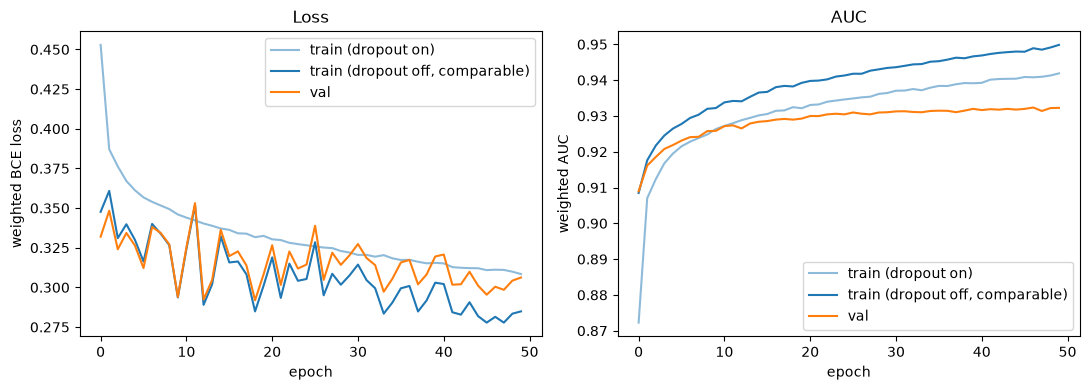

Final weighted AUC: train=0.9489 val=0.9323


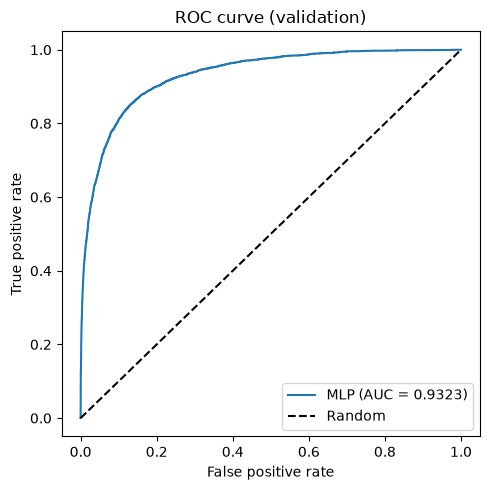

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

# NOTE: the faint "train (dropout on)" curve is measured mid-training with
# dropout active and class-balanced fit-weights - it's what the optimizer
# actually sees, not a fair comparison to val. The solid "train (dropout
# off, comparable)" curve (same eval mode + |w_phys| weights as val) is the
# one to read an honest train/val gap off of.

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(torch.tensor(X_train_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()
    val_probs = torch.sigmoid(model(torch.tensor(X_val_scaled, dtype=torch.float32).to(DEVICE))).cpu().numpy()

auc_train = roc_auc_score(y_train, train_probs, sample_weight=np.abs(w_train))
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_fit)

print(f"Final weighted AUC: train={auc_train:.4f} val={auc_val:.4f}")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_fit)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"MLP (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation)")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation)

XGBoost has a built-in gain-based importance, but a neural net doesn't - the
model-agnostic equivalent is **permutation importance**: shuffle one
feature's column across events (destroying its relationship with the
label) and measure how much the weighted validation AUC drops. Repeated a
few times per feature and averaged for stability. Computed on the
validation set so it isn't inflated by the model simply memorizing train.

In [14]:
def permutation_importance(model, X, y, w, features, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors (e.g. X_val_t/y_val_t/w_val_t) with columns in the
    same order as `features`. Returns a pandas Series (feature -> mean AUC
    drop), sorted descending - a bigger drop means the model relies on that
    feature more.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []
    
    for i, feat in enumerate(features):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=features, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance (same
    convention as the XGBoost master pipeline's plot_importance_bar). If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()

Baseline weighted AUC: 0.9323


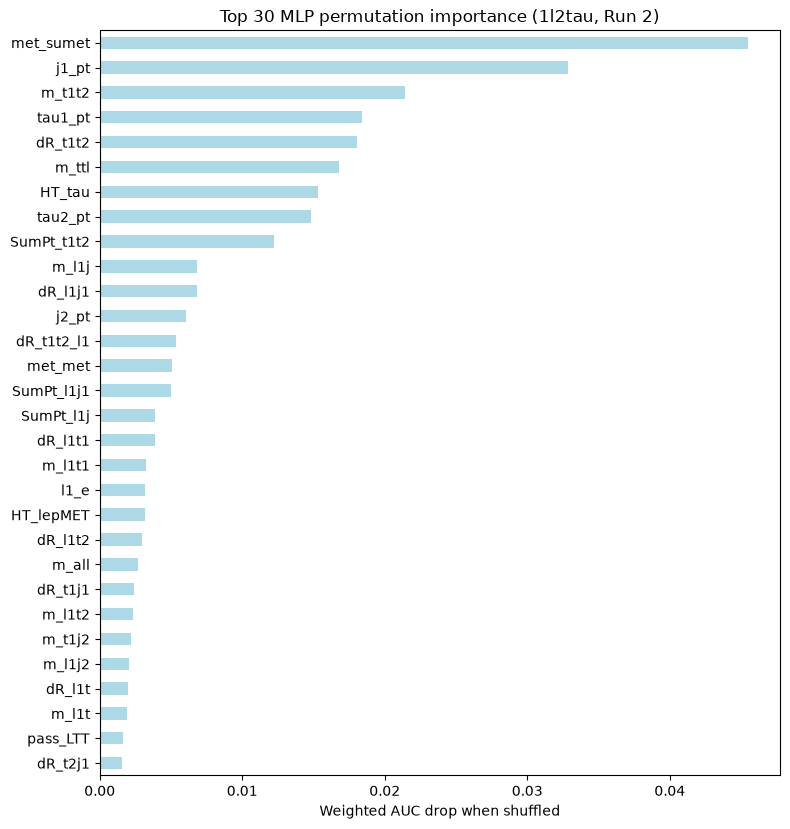

met_sumet     0.045459
j1_pt         0.032884
m_t1t2        0.021390
tau1_pt       0.018389
dR_t1t2       0.018032
m_ttl         0.016792
HT_tau        0.015298
tau2_pt       0.014794
SumPt_t1t2    0.012262
m_l1j         0.006847
dR_l1j1       0.006824
j2_pt         0.006075
dR_t1t2_l1    0.005328
met_met       0.005093
SumPt_l1j1    0.005028
Name: auc_drop, dtype: float64

In [15]:
importance = permutation_importance(model, X_val_t, y_val_t, w_val_t, features, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Run 2)")
importance.head(15)

## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's correlation-pruning stage: rank
features by importance (permutation importance here, gain there), look at
Pearson correlation among the top candidates separately for signal and
background, then walk the ranked list keeping a feature only if it isn't
too correlated (`|corr| > 0.75`) with a more important feature already kept.
The MLP is then retrained from scratch on the decorrelated feature set, and
again restricted to just the top 15 features, to see how much (if any)
performance is lost by cutting redundant/less useful inputs.

In [16]:
TOP_N_IMPORTANCE = 30   # candidate pool size, before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""
    
    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)
    
    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors(feature_subset, all_features=features):
    
    """
    Slice the already-scaled train/val/test numpy arrays down to
    `feature_subset` (columns picked by name, matching `all_features`'
    order) and move the result to GPU-resident tensors - the same shape
    train_model expects. The test slice is never used for training/model
    selection - it exists only so the eventually-chosen final model can be
    scored on test once, at the end.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t

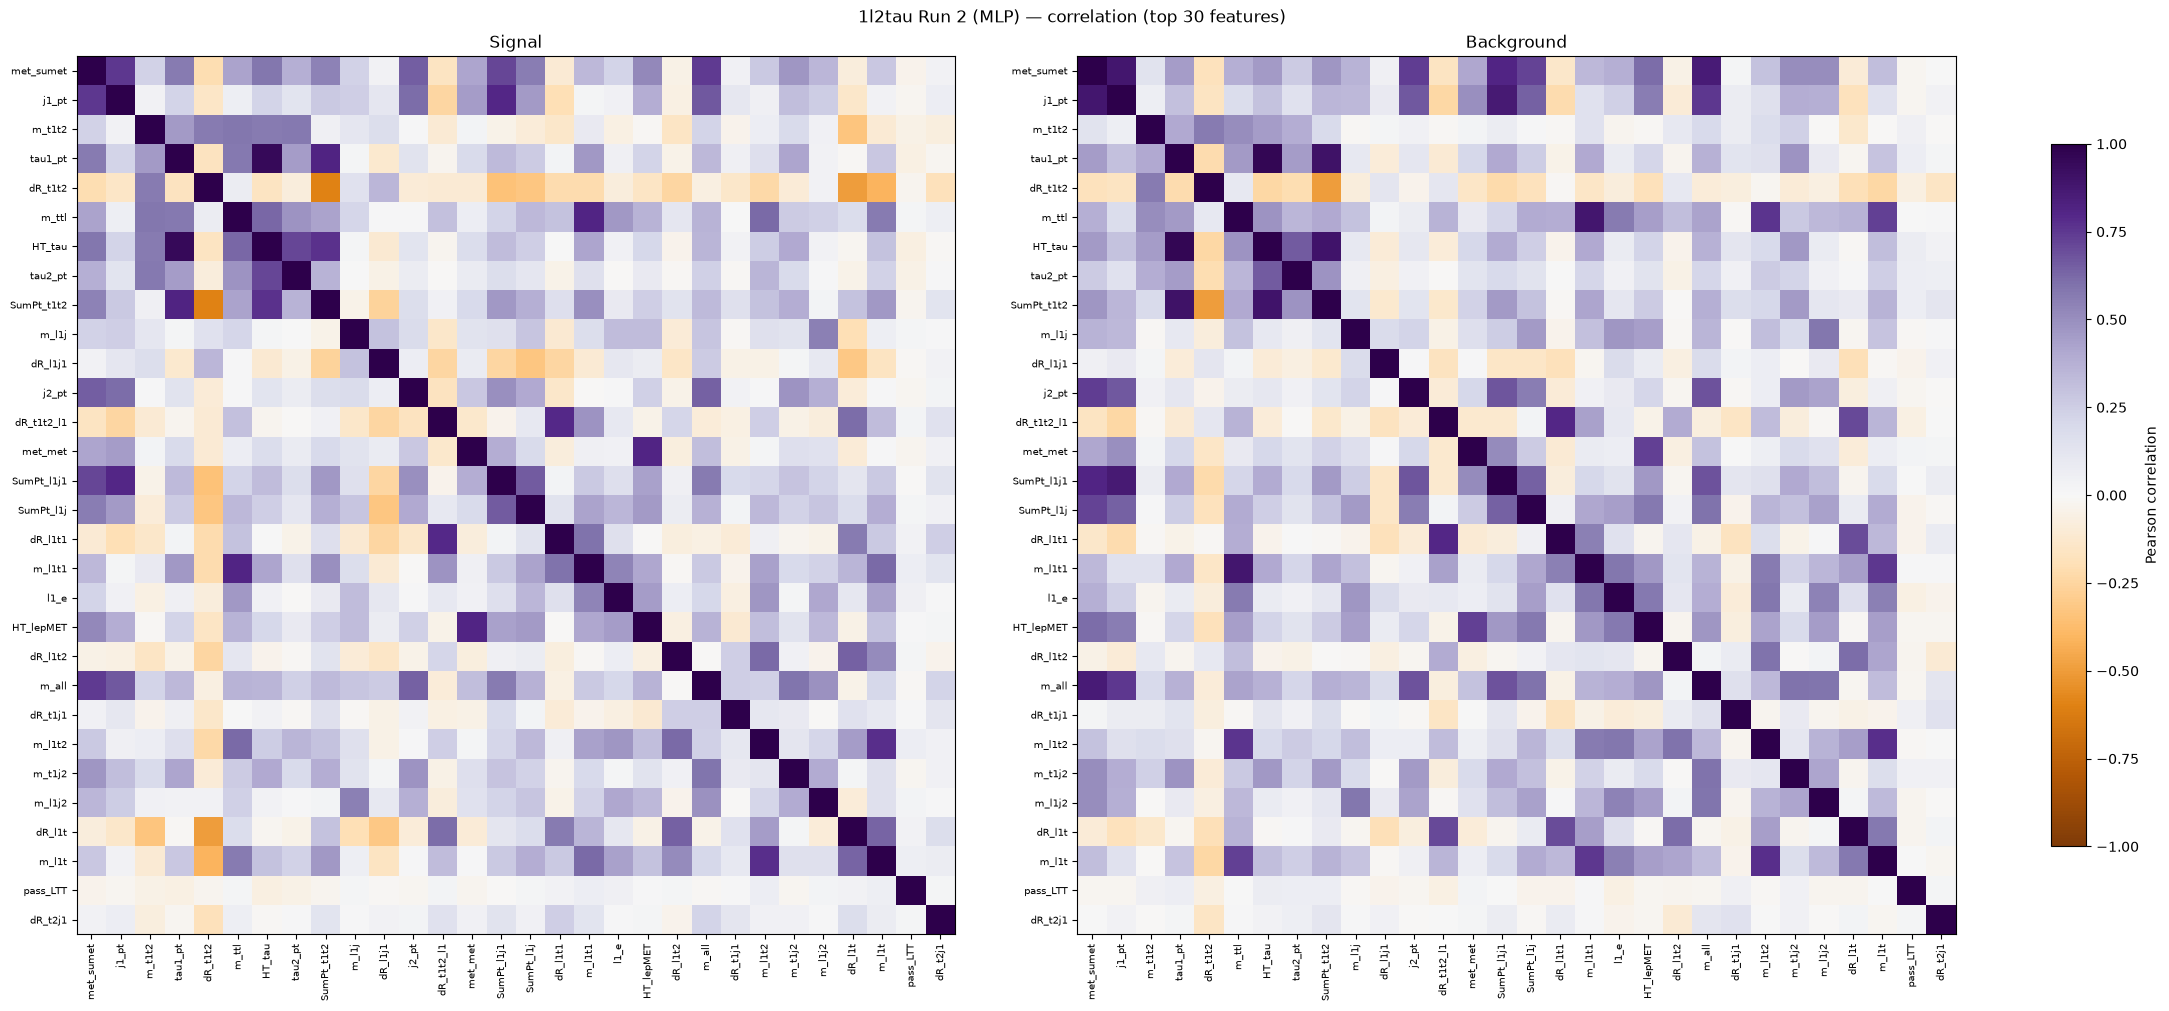

Pairs with |corr| > 0.50 (signal):
tau1_pt     HT_tau        0.945766
            SumPt_t1t2    0.812904
met_met     HT_lepMET     0.810867
m_ttl       m_l1t1        0.805546
j1_pt       SumPt_l1j1    0.802792
dR_t1t2_l1  dR_l1t1       0.794670
m_l1t2      m_l1t         0.776330
HT_tau      SumPt_t1t2    0.768862
met_sumet   j1_pt         0.755326
            m_all         0.746627
HT_tau      tau2_pt       0.716004
met_sumet   SumPt_l1j1    0.711588

Pairs with |corr| > 0.50 (background):
tau1_pt     HT_tau        0.967306
            SumPt_t1t2    0.903307
HT_tau      SumPt_t1t2    0.894850
met_sumet   j1_pt         0.882017
m_ttl       m_l1t1        0.876889
j1_pt       SumPt_l1j1    0.863127
met_sumet   m_all         0.859209
            SumPt_l1j1    0.804778
dR_t1t2_l1  dR_l1t1       0.798424
m_l1t2      m_l1t         0.779582
m_ttl       m_l1t2        0.759981
j1_pt       m_all         0.750723
m_l1t1      m_l1t         0.750173
met_sumet   j2_pt         0.736223
met_met     HT_

In [17]:
# ---- Correlation of the top-30 permutation-important features -------------

top_feats = importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(data, top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"1l2tau Run 2 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())

In [18]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. tau1_pt
   4. dR_t1t2
   5. m_ttl
   6. tau2_pt
   7. m_l1j
   8. dR_l1j1
   9. j2_pt
  10. dR_t1t2_l1
  11. met_met
  12. SumPt_l1j
  13. l1_e
  14. dR_l1t2
  15. dR_t1j1
  16. m_t1j2
  17. m_l1j2
  18. dR_l1t
  19. m_l1t
  20. pass_LTT

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.805)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  m_all           -> redundant with met_sumet       (|corr| = 0.859)
  m_l1t2          -> redundant with m_ttl

Full model      (64 features): train_auc_eval = 0.9489 | val_auc = 0.9323
Pruned model     (20 features): train_auc_eval = 0.9391 | val_auc = 0.9327
Baseline weighted AUC: 0.9327


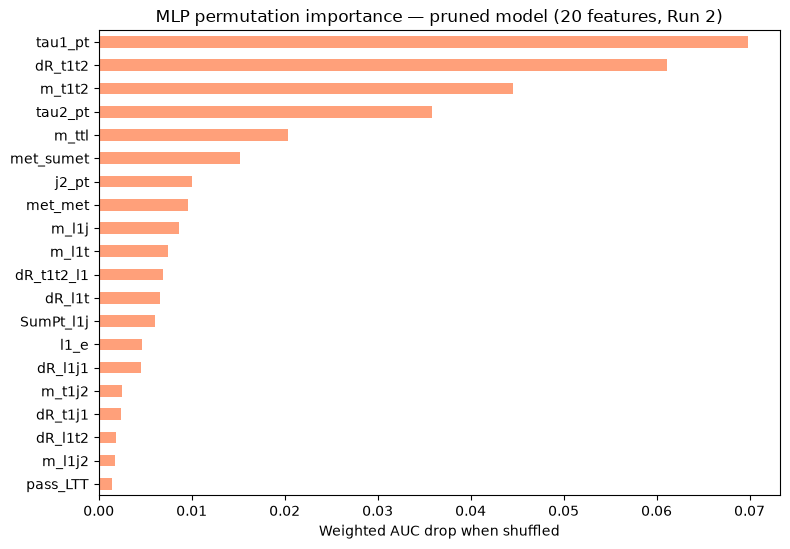

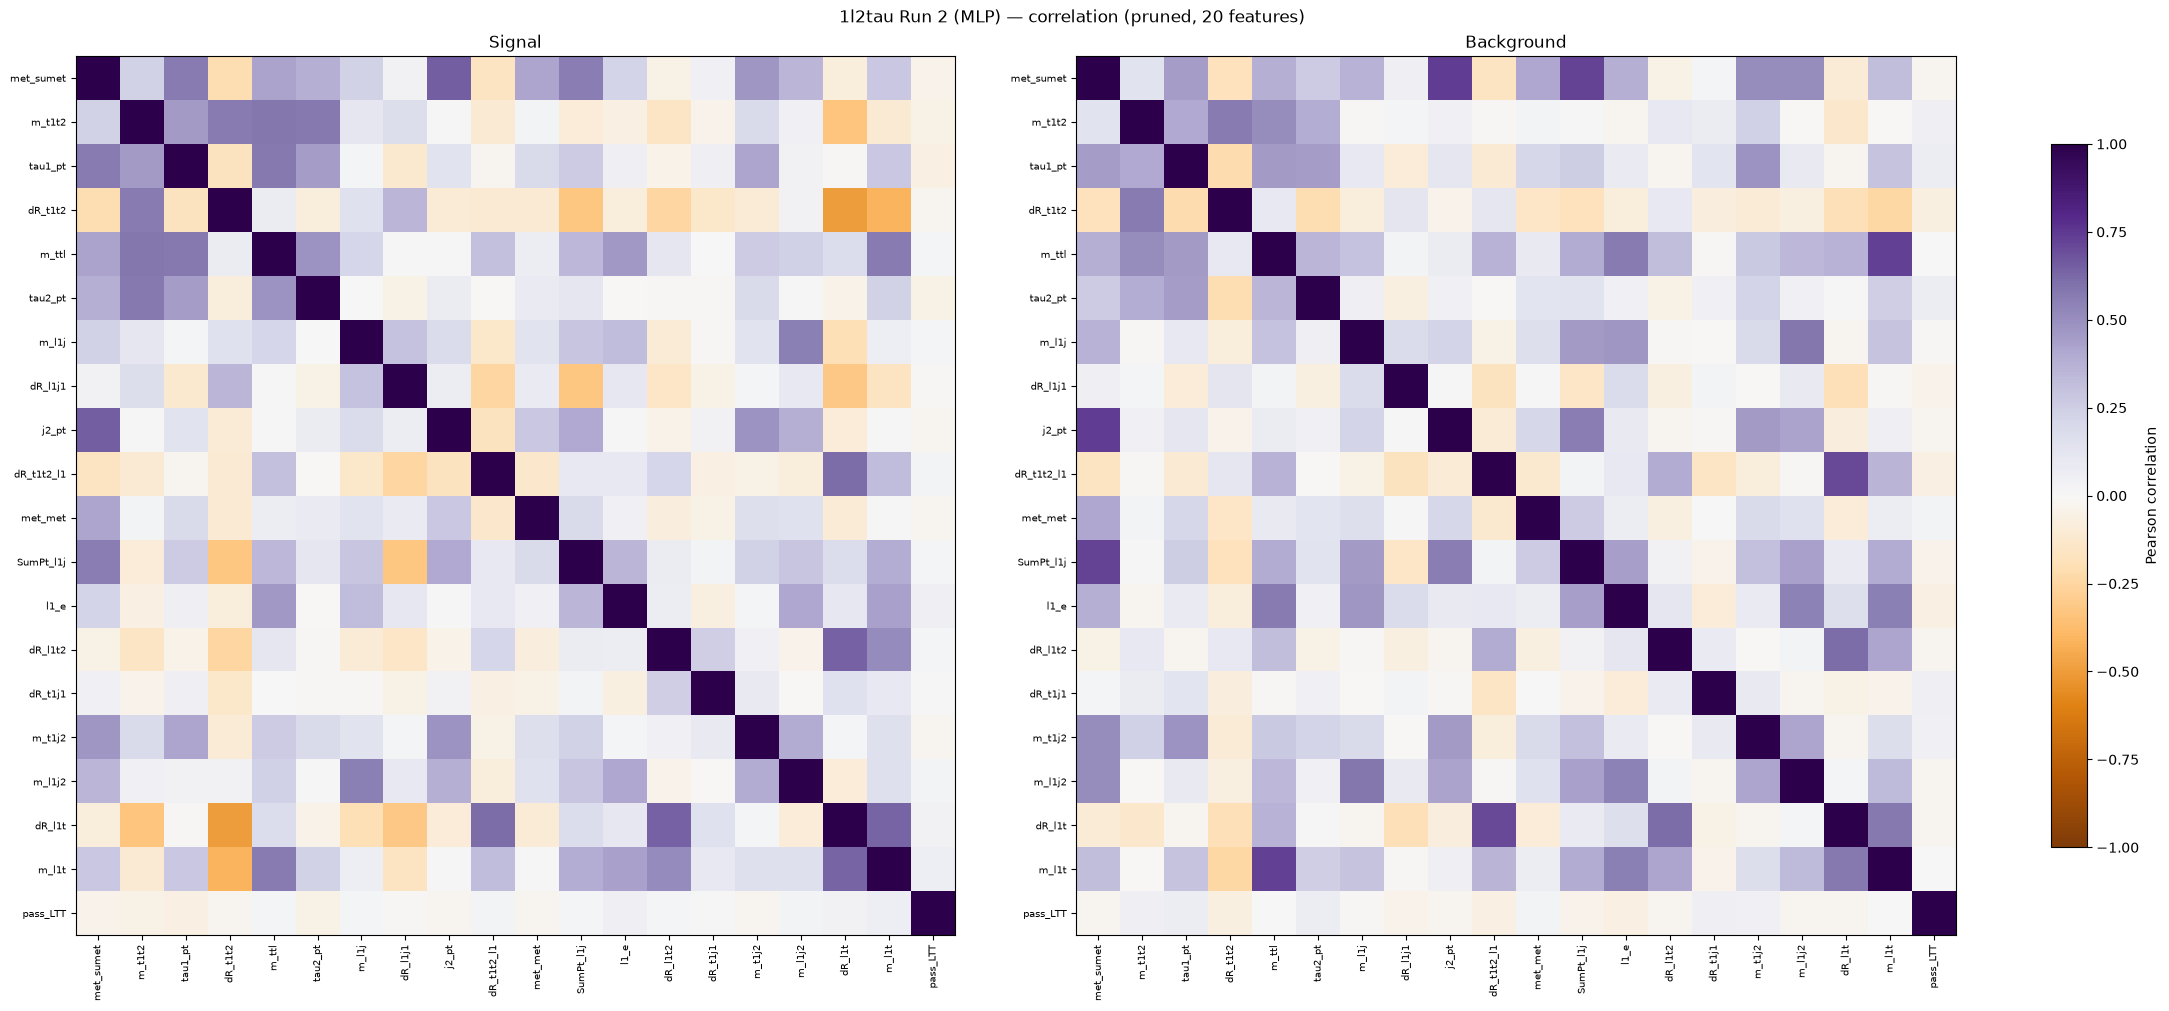

In [19]:
# ---- Retrain on the pruned feature set --------------------------------
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors(PRUNED_FEATURES)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    hidden_sizes=best_hidden_sizes, verbose=False,
    X_train_data=X_train_pruned_t, X_val_data=X_val_pruned_t,
)

print(f"Full model      ({len(features):2d} features): train_auc_eval = {best_train_auc_eval:.4f} | val_auc = {best_val_auc:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES):2d} features): train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, y_val_t, w_val_t, PRUNED_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_FEATURES),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES)} features, Run 2)",
    color="lightsalmon",
)

pruned_corrs = grouped_correlations(data, PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"1l2tau Run 2 (MLP) — correlation (pruned, {len(PRUNED_FEATURES)} features)",
)

## Top-15 Features Only

Same correlation-pruning walk over the same top-30 candidate pool, but
stopped once 15 decorrelated features are kept, to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set.

Kept 15 decorrelated features (most -> least important):
   1. met_sumet
   2. m_t1t2
   3. tau1_pt
   4. dR_t1t2
   5. m_ttl
   6. tau2_pt
   7. m_l1j
   8. dR_l1j1
   9. j2_pt
  10. dR_t1t2_l1
  11. met_met
  12. SumPt_l1j
  13. l1_e
  14. dR_l1t2
  15. dR_t1j1

Dropped 8 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.882)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.805)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.877)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.811)
  m_all           -> redundant with met_sumet       (|corr| = 0.859)


Baseline weighted AUC: 0.9313


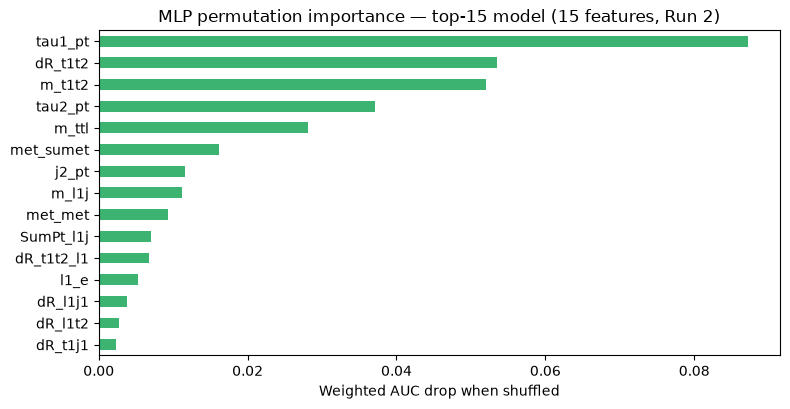


Weighted train(eval-mode)/validation AUC comparison:


,model,train_auc_eval,val_auc
1,Pruned (20 features),0.939135,0.932705
0,Full (64 features),0.948902,0.932344
2,Top-15 (15 features),0.936364,0.931278


In [20]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors(TOP15_FEATURES)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    hidden_sizes=best_hidden_sizes, verbose=False,
    X_train_data=X_train_top15_t, X_val_data=X_val_top15_t,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, y_val_t, w_val_t, TOP15_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_FEATURES),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES)} features, Run 2)",
    color="mediumseagreen",
)

comparison = pd.DataFrame([
    {"model": f"Full ({len(features)} features)", "train_auc_eval": best_train_auc_eval, "val_auc": best_val_auc},
    {"model": f"Pruned ({len(PRUNED_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned, "val_auc": val_auc_pruned},
    {"model": f"Top-15 ({len(TOP15_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15, "val_auc": val_auc_top15},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison:")
comparison

## Physics Figure of Merit & Final Summary

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This section reports a max-Asimov-significance
scan for the **last pruned model (top-15 features)** - the most
decorrelated/interpretable feature set from the pruning walk above - plus a
low-FPR ROC view and signal efficiency at fixed background-rejection
working points, all still on **VAL** (used for model/cut selection).

A genuinely blind estimate follows in the "Held-Out Test Evaluation" cell
below: the VAL-selected score cut is applied FROZEN to the never-before-seen
**TEST** partition (10% of the sample, held out by `make_3way_split` since
before preprocessing), reporting test AUC and test Z at that cut exactly
once - this is what actually answers "how good is this model", since VAL
was used to pick both the model and the cut.

In [21]:
def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """
    Max Asimov significance over score cuts. Uses SIGNED w_phys (expected
    yields, not |w_phys|) - S and B are physical yields, not event counts.
    `min_bkg` guards the sparse high-score tail where Z is unstable/
    unphysical when B is tiny or negative. Caveat: signed sums CAN drive S
    or B negative in sparse bins (the S>0/min_bkg guards handle it); the
    absolute Z value depends on sample normalization/luminosity, so treat it
    as a RELATIVE metric for ranking models on the identical rows, not an
    absolute discovery number.
    """

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None

    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))  # Asimov; -> S/sqrt(B) for S<<B
        if z > best_z:
            best_z, best_t = z, t

    return best_z, best_t


# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the pruning walk above. The score CUT is
# selected here by scanning VAL only - it is applied FROZEN to test in the
# "Held-Out Test Evaluation" cell below, never re-scanned there.
models_registry = {
    f"Full ({len(features)} features)": (model, X_val_t, X_test_t),
    f"Pruned ({len(PRUNED_FEATURES)} features)": (model_pruned, X_val_pruned_t, X_test_pruned_t),
    f"Top-15 ({len(TOP15_FEATURES)} features)": (model_top15, X_val_top15_t, X_test_top15_t),
}
best_name = f"Top-15 ({len(TOP15_FEATURES)} features)"

final_model, X_val_final_t, X_test_final_t = models_registry[best_name]

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

z_val, thr_val = significance_scan(y_val, val_scores, w_val)  # signed w_phys - expected yields
final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name}")
print(f"Weighted val AUC = {final_val_auc:.4f}")
print(f"Max Asimov Z (val) = {z_val:.3f} at score cut = {thr_val:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9313
Max Asimov Z (val) = 0.028 at score cut = 0.9790


### Held-Out Test Evaluation (Run 2)

`X_test_final_t`/`y_test`/`w_test` have not participated in anything above -
not the imputation/scaler fit, not correlation pruning, not hyperparameter
search, not early stopping, not the score-cut selection just above. This is
the one place they are read: the final model is scored once, and the
VAL-selected score cut is applied frozen (not re-scanned).


In [22]:
# ---- HELD-OUT TEST EVALUATION (Run 2) — scored EXACTLY ONCE ----------------
# X_test_final_t/y_test/w_test have not been touched anywhere above (not the
# imputation/scaler fit, not correlation pruning, not hyperparameter search,
# not early stopping, not the significance-scan score-cut selection just
# above) - this is the only cell in the Run 2 section that reads them. The
# score cut `thr_val` was chosen by scanning VAL only; it is applied here
# FROZEN, NOT re-scanned on test.

final_model.eval()
with torch.no_grad():
    test_scores = torch.sigmoid(final_model(X_test_final_t)).cpu().numpy()

auc_test = roc_auc_score(y_test, test_scores, sample_weight=w_test_fit)

S_test = w_test[(test_scores >= thr_val) & (y_test == 1)].sum()
B_test = w_test[(test_scores >= thr_val) & (y_test == 0)].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"Final model: {best_name}")
print(f"Weighted AUC: val = {final_val_auc:.4f}  |  test (held-out, scored once) = {auc_test:.4f}")
print(f"At the VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test:.2f} | test B = {B_test:.2f} | test Z = {z_test:.3f}  (val Z was {z_val:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9313  |  test (held-out, scored once) = 0.9347
At the VAL-selected score cut = 0.9790 (frozen, NOT re-scanned on test):
  test S = 0.03 | test B = 1.10 | test Z = 0.031  (val Z was 0.028)


In [25]:
# ---- Load the tuned XGBoost model (same 1l2tau Run 2 track) for an
# apples-to-apples overlay. Both notebooks build `data` identically and
# split 80/20 with the same seed/stratify-on-label, so val_df here is the
# same event set as the XGBoost pipeline's holdout - no need to reload data.

import xgboost as xgb

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(BASE_DIR / "final_model_run2.json")
with open(BASE_DIR / "optuna_features_run2.json") as f:
    xgb_features = json.load(f)

xgb_val_scores = xgb_model.predict_proba(val_df[xgb_features])[:, 1]


def roc_with_auc(y_true, scores, w):
    fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=w)
    auc = roc_auc_score(y_true, scores, sample_weight=w)
    return fpr, tpr, auc


# Model-vs-model overlay on the SAME val rows/|w_phys| weights - this is the
# plot that actually answers "which model holds more signal at fixed
# background rejection", not a single curve vs. a (wrong) diagonal.

# ROC curve for the FINAL model (top-15 pruned, `val_scores` from the
# significance-scan cell above), not the full model - matches the `best_name` label.
fpr_val, tpr_val, _ = roc_curve(y_val, val_scores, sample_weight=w_val_fit)

curves = {
    "XGBoost (tuned)": roc_with_auc(y_val, xgb_val_scores, w_val_fit),
    f"MLP Full ({len(features)} features)": roc_with_auc(y_val, val_probs, w_val_fit),
    f"MLP {best_name}": (fpr_val, tpr_val, final_val_auc),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")


x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val)")
plt.legend()
plt.tight_layout()
plt.show()

# Caveat: below ~1e-3 FPR the surviving background is down to O(100) MC
# events, so the leftmost decade - especially any uptick right at the 1e-4
# edge - is statistical wobble, not a real effect. 

n_bkg_val = int((y_val == 0).sum())

for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

KeyError: "['tau2_charge'] not in index"

In [ ]:
# ---- Sanity checks --------------------------------------------------------

assert np.isfinite(X_train_scaled).all() and np.isfinite(X_val_scaled).all() and np.isfinite(X_test_scaled).all(), \
    "NaN/inf reached the model input"

# Determinism check (Task 1's acceptance criterion): re-seeding immediately
# before each of two short training runs should give an EXACT match, proving
# set_seed()/use_deterministic_algorithms(True) actually pin every source of
# randomness (weight init, dropout masks, batch shuffling). Uses a cheap
# config (small model, 5 epochs) purely to keep this check fast - it is not
# meant to reflect final model quality.

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False)
assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test, z_test at the frozen,
# VAL-selected score cut).

summary = pd.DataFrame([{
    "model": best_name,
    "train_auc_eval": final_train_auc_eval,
    "val_auc": final_val_auc,
    "max_asimov_Z (val)": z_val,
    "test_auc (held-out, scored once)": auc_test,
    "test_Z_at_val_cut (held-out)": z_test,
}])

print("\nFinal summary (MLP, 1l2tau Run 2):")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.912899

Final summary (MLP, 1l2tau Run 2):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.936364 0.931278            0.028384                          0.934655                      0.031293


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.936364,0.931278,0.028384,0.934655,0.031293


## Run 3 (Separate Downstream Section)

Run 2 remains the first complete pass above. To start a separate Run 3 pass,
run the next cell to switch the active dataset, then continue with your
Run 3 downstream cells.

In [ ]:
# Activate Run 3 as the downstream dataset. Everything below uses `_run3`
# suffixed variable names so the Run 2 results above remain untouched.

candidate_features, data, features = candidate_features_run3, data_run3, features_run3

BASE_DIR = BASE_DIR_RUN3
ACTIVE_RUN = "Run 3"

print(f"Switched downstream dataset to: {ACTIVE_RUN}")
print(f"Events={len(data)} | features={len(features)}")

Switched downstream dataset to: Run 3
Events=1324892 | features=68


## Sentinel Audit (-1) — Run 3

Same diagnostic as the Run 2 section above, run separately on `data_run3`/
`features_run3`.

In [ ]:
NEG1_SENTINEL_FEATURES_run3 = set()

neg1_rows_run3 = []
for f in features_run3:
    vals = data_run3[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_run3.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_run3 = pd.DataFrame(neg1_rows_run3).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_run3)} / {len(features_run3)} features have at least one row exactly equal to -1:")
print(neg1_df_run3.to_string(index=False))

# Apply the (currently empty) mask before the train/val split, same convention as Run 2.
for f in NEG1_SENTINEL_FEATURES_run3:
    data_run3[f] = data_run3[f].mask(data_run3[f] == -1)
if NEG1_SENTINEL_FEATURES_run3:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_run3)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.")

3 / 68 features have at least one row exactly equal to -1:
    feature  frac_exactly_-1  gap_to_next_value_above
tau1_charge         0.495634                      2.0
tau2_charge         0.489882                      2.0
  l1_charge         0.474795                      2.0

NEG1_SENTINEL_FEATURES_run3 is empty - no -1 values masked.


## Train/Validation Split & Preprocessing — Run 3

Same 80/20 stratified split, median imputation (fit on train only),
standard scaling, and `__isnan` missingness flags as the Run 2 section,
applied to `data_run3`. Kept in separate `_run3` variables so the Run 2
train/val tensors above are unaffected.

In [ ]:
train_df_run3, val_df_run3, test_df_run3 = make_3way_split(data_run3)

SPLIT_DIR_RUN3 = BASE_DIR_RUN3 / "splits"
persist_test_partition(test_df_run3, SPLIT_DIR_RUN3)

X_train_raw_run3, y_train_run3, w_train_run3 = train_df_run3[features_run3], train_df_run3["label"].to_numpy(), train_df_run3["w_phys"].to_numpy()
X_val_raw_run3,   y_val_run3,   w_val_run3   = val_df_run3[features_run3],   val_df_run3["label"].to_numpy(),   val_df_run3["w_phys"].to_numpy()
X_test_raw_run3,  y_test_run3,  w_test_run3  = test_df_run3[features_run3],  test_df_run3["label"].to_numpy(),  test_df_run3["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train_run3 = X_train_raw_run3.isna()
flag_cols_run3 = nan_train_run3.columns[nan_train_run3.any()].tolist()


def make_flags_run3(X_raw):
    """Run 3 version of make_flags: 0/1 missingness flags for `flag_cols_run3`."""
    f = X_raw[flag_cols_run3].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols_run3]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians_run3 = X_train_raw_run3.median()
X_train_imp_run3 = X_train_raw_run3.fillna(train_medians_run3)
X_val_imp_run3 = X_val_raw_run3.fillna(train_medians_run3)
X_test_imp_run3 = X_test_raw_run3.fillna(train_medians_run3)

scaler_run3 = StandardScaler()
X_train_scaled_run3 = np.hstack([scaler_run3.fit_transform(X_train_imp_run3), make_flags_run3(X_train_raw_run3).to_numpy()])
X_val_scaled_run3 = np.hstack([scaler_run3.transform(X_val_imp_run3), make_flags_run3(X_val_raw_run3).to_numpy()])
X_test_scaled_run3 = np.hstack([scaler_run3.transform(X_test_imp_run3), make_flags_run3(X_test_raw_run3).to_numpy()])

assert np.isfinite(X_train_scaled_run3).all(), "NaN/inf reached the model input (train, Run 3)"
assert np.isfinite(X_val_scaled_run3).all(), "NaN/inf reached the model input (val, Run 3)"
assert np.isfinite(X_test_scaled_run3).all(), "NaN/inf reached the model input (test, Run 3)"

print(f"\n{len(flag_cols_run3)} features had missing values in train -> added {len(flag_cols_run3)} __isnan flag "
      f"columns (final input width = {X_train_scaled_run3.shape[1]} = {len(features_run3)} features + {len(flag_cols_run3)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.
w_train_fit_run3 = make_fit_weights(y_train_run3, np.abs(w_train_run3))
w_train_abs_run3 = np.abs(w_train_run3)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit_run3 = np.abs(w_val_run3)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end.
w_test_fit_run3 = np.abs(w_test_run3)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train_run3[y_train_run3==0]).sum() / np.abs(w_train_run3[y_train_run3==1]).sum():.1f}")


Train:  1059912 events | signal =  164040 (yield=      1.67) | background =  895872 (yield=  15588.90) | signal weight scale factor = 9358.6
Val  :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1910.84) | signal weight scale factor = 9270.7
Test :   132490 events | signal =   20505 (yield=      0.21) | background =  111985 (yield=   1867.19) | signal weight scale factor = 8929.3
  cross-check OK: PPSSP_2026/1l2tau/run3/splits/test.root test partition matches on 73 shared columns (132490 rows)
Wrote 132490 test events -> PPSSP_2026/1l2tau/run3/splits/test.root  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 68 = 68 features + 0 flags)
Signal weight scale factor (train): 12537.2


## PyTorch Dataset & Model — Run 3

In [ ]:
X_train_t_run3 = torch.tensor(X_train_scaled_run3, dtype=torch.float32, device=DEVICE)
y_train_t_run3 = torch.tensor(y_train_run3, dtype=torch.float32, device=DEVICE)
w_train_t_run3 = torch.tensor(w_train_fit_run3, dtype=torch.float32, device=DEVICE)
w_train_abs_t_run3 = torch.tensor(w_train_abs_run3, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t_run3 = torch.tensor(X_val_scaled_run3, dtype=torch.float32, device=DEVICE)
y_val_t_run3 = torch.tensor(y_val_run3, dtype=torch.float32, device=DEVICE)
w_val_t_run3 = torch.tensor(w_val_fit_run3, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section.
X_test_t_run3 = torch.tensor(X_test_scaled_run3, dtype=torch.float32, device=DEVICE)
y_test_t_run3 = torch.tensor(y_test_run3, dtype=torch.float32, device=DEVICE)
w_test_t_run3 = torch.tensor(w_test_fit_run3, dtype=torch.float32, device=DEVICE)

model_run3 = build_model(n_features=X_train_scaled_run3.shape[1])

print(model_run3)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Run 3

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_run3` tensors passed in so the Run 2 model/
history are untouched.

In [ ]:
model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = train_model(
    hidden_sizes=DEFAULT_HIDDEN_SIZES,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

print(f"\nBest val_auc = {best_val_auc_run3:.4f} | train_auc (dropout on) = {best_train_auc_run3:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_run3:.4f}")

Epoch   1 | train_loss=0.4564 val_loss=0.5112 | train_auc=0.8724 train_auc_eval=0.9226 val_auc=0.9018
Epoch   2 | train_loss=0.3702 val_loss=0.4226 | train_auc=0.9165 train_auc_eval=0.9306 val_auc=0.9117
Epoch   3 | train_loss=0.3555 val_loss=0.4184 | train_auc=0.9229 train_auc_eval=0.9355 val_auc=0.9171
Epoch   4 | train_loss=0.3435 val_loss=0.3016 | train_auc=0.9282 train_auc_eval=0.9390 val_auc=0.9355
Epoch   5 | train_loss=0.3359 val_loss=0.3557 | train_auc=0.9314 train_auc_eval=0.9422 val_auc=0.9303


Epoch   6 | train_loss=0.3296 val_loss=0.3352 | train_auc=0.9339 train_auc_eval=0.9446 val_auc=0.9392
Epoch   7 | train_loss=0.3259 val_loss=0.3308 | train_auc=0.9355 train_auc_eval=0.9466 val_auc=0.9412
Epoch   8 | train_loss=0.3203 val_loss=0.3196 | train_auc=0.9377 train_auc_eval=0.9473 val_auc=0.9418
Epoch   9 | train_loss=0.3162 val_loss=0.3047 | train_auc=0.9393 train_auc_eval=0.9481 val_auc=0.9426
Epoch  10 | train_loss=0.3156 val_loss=0.3214 | train_auc=0.9395 train_auc_eval=0.9503 val_auc=0.9442
Epoch  11 | train_loss=0.3114 val_loss=0.3831 | train_auc=0.9411 train_auc_eval=0.9507 val_auc=0.9307
Epoch  12 | train_loss=0.3079 val_loss=0.3577 | train_auc=0.9426 train_auc_eval=0.9528 val_auc=0.9456
Epoch  13 | train_loss=0.3062 val_loss=0.3365 | train_auc=0.9431 train_auc_eval=0.9531 val_auc=0.9452
Epoch  14 | train_loss=0.3037 val_loss=0.3032 | train_auc=0.9440 train_auc_eval=0.9547 val_auc=0.9462
Epoch  15 | train_loss=0.3022 val_loss=0.3577 | train_auc=0.9446 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Run 3

In [ ]:
search_results_run3 = []
best_search_auc_run3, best_hidden_sizes_run3 = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(
        hidden_sizes=hidden_sizes, verbose=False,
        X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
        X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
        w_train_eval_data=w_train_abs_t_run3,
    )
    search_results_run3.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc_run3:
        best_search_auc_run3, best_hidden_sizes_run3 = trial_val_auc, hidden_sizes
        model_run3, history_run3, best_val_auc_run3, best_train_auc_run3, best_train_auc_eval_run3 = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes_run3} | val_auc={best_search_auc_run3:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9332 val_auc=0.9256
hidden_sizes=(128, 64)        -> train_auc=0.9392 val_auc=0.9401
hidden_sizes=(256, 128)       -> train_auc=0.9463 val_auc=0.9470
hidden_sizes=(128, 64, 32)    -> train_auc=0.9398 val_auc=0.9419
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9443 val_auc=0.9468

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9470


## Evaluation — Run 3

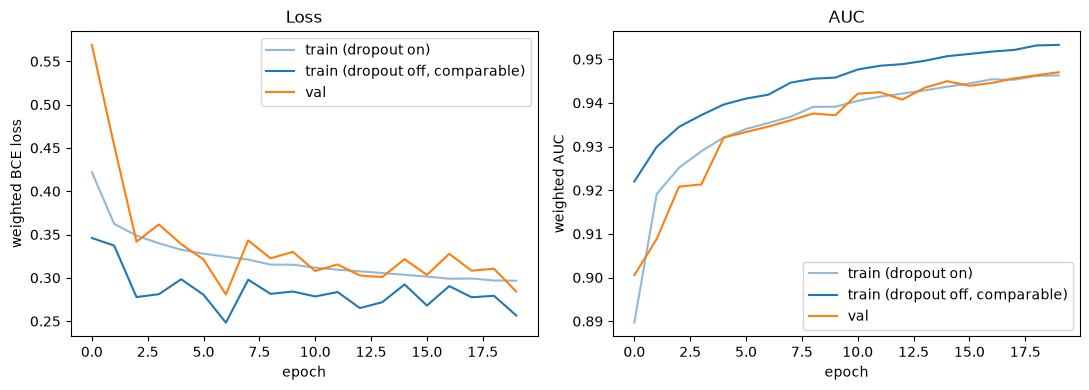

Final weighted AUC: train=0.9533 val=0.9470


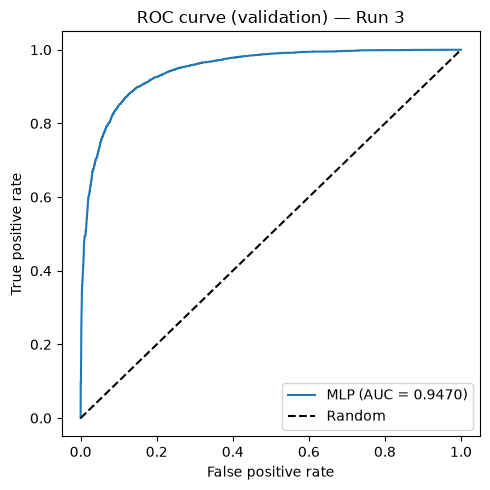

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_run3["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_run3["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_run3["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_run3["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_run3["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_run3["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_run3.eval()
with torch.no_grad():
    train_probs_run3 = torch.sigmoid(model_run3(X_train_t_run3)).cpu().numpy()
    val_probs_run3 = torch.sigmoid(model_run3(X_val_t_run3)).cpu().numpy()

auc_train_run3 = roc_auc_score(y_train_run3, train_probs_run3, sample_weight=np.abs(w_train_run3))
auc_val_run3 = roc_auc_score(y_val_run3, val_probs_run3, sample_weight=w_val_fit_run3)

print(f"Final weighted AUC: train={auc_train_run3:.4f} val={auc_val_run3:.4f}")

fpr_run3, tpr_run3, _ = roc_curve(y_val_run3, val_probs_run3, sample_weight=w_val_fit_run3)
plt.figure(figsize=(5, 5))
plt.plot(fpr_run3, tpr_run3, label=f"MLP (AUC = {auc_val_run3:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Run 3")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Run 3

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9470


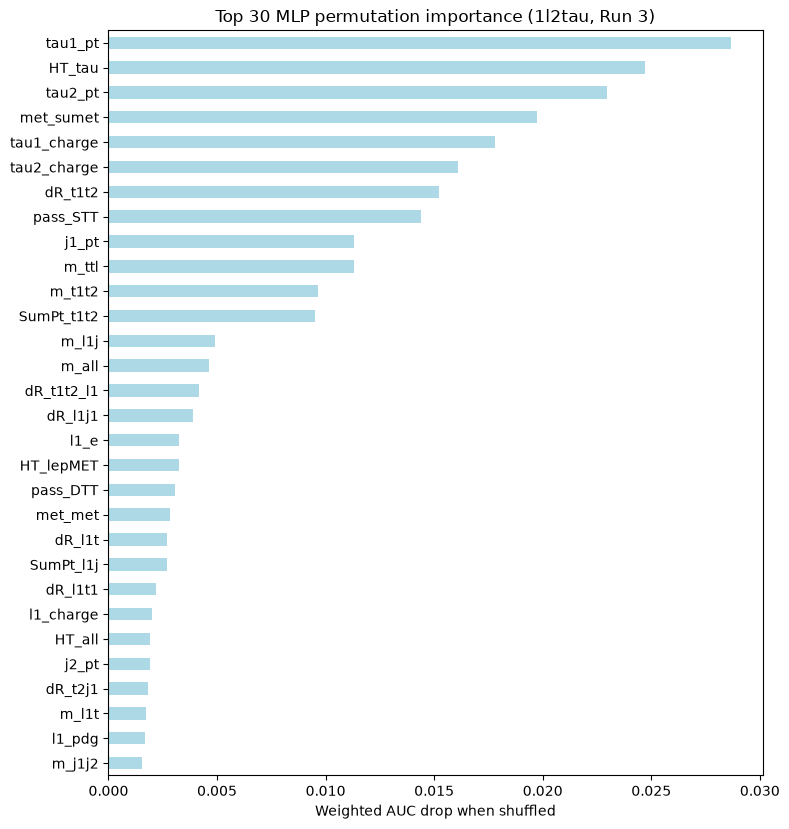

tau1_pt        0.028688
HT_tau         0.024731
tau2_pt        0.022980
met_sumet      0.019737
tau1_charge    0.017788
tau2_charge    0.016078
dR_t1t2        0.015230
pass_STT       0.014391
j1_pt          0.011313
m_ttl          0.011285
m_t1t2         0.009644
SumPt_t1t2     0.009525
m_l1j          0.004928
m_all          0.004620
dR_t1t2_l1     0.004175
Name: auc_drop, dtype: float64

In [ ]:
importance_run3 = permutation_importance(model_run3, X_val_t_run3, y_val_t_run3, w_val_t_run3, features_run3, n_repeats=5)
plot_importance_bar(importance_run3, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Run 3)")
importance_run3.head(15)

## Correlation Pruning & Retraining — Run 3

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on Run 3 inputs).

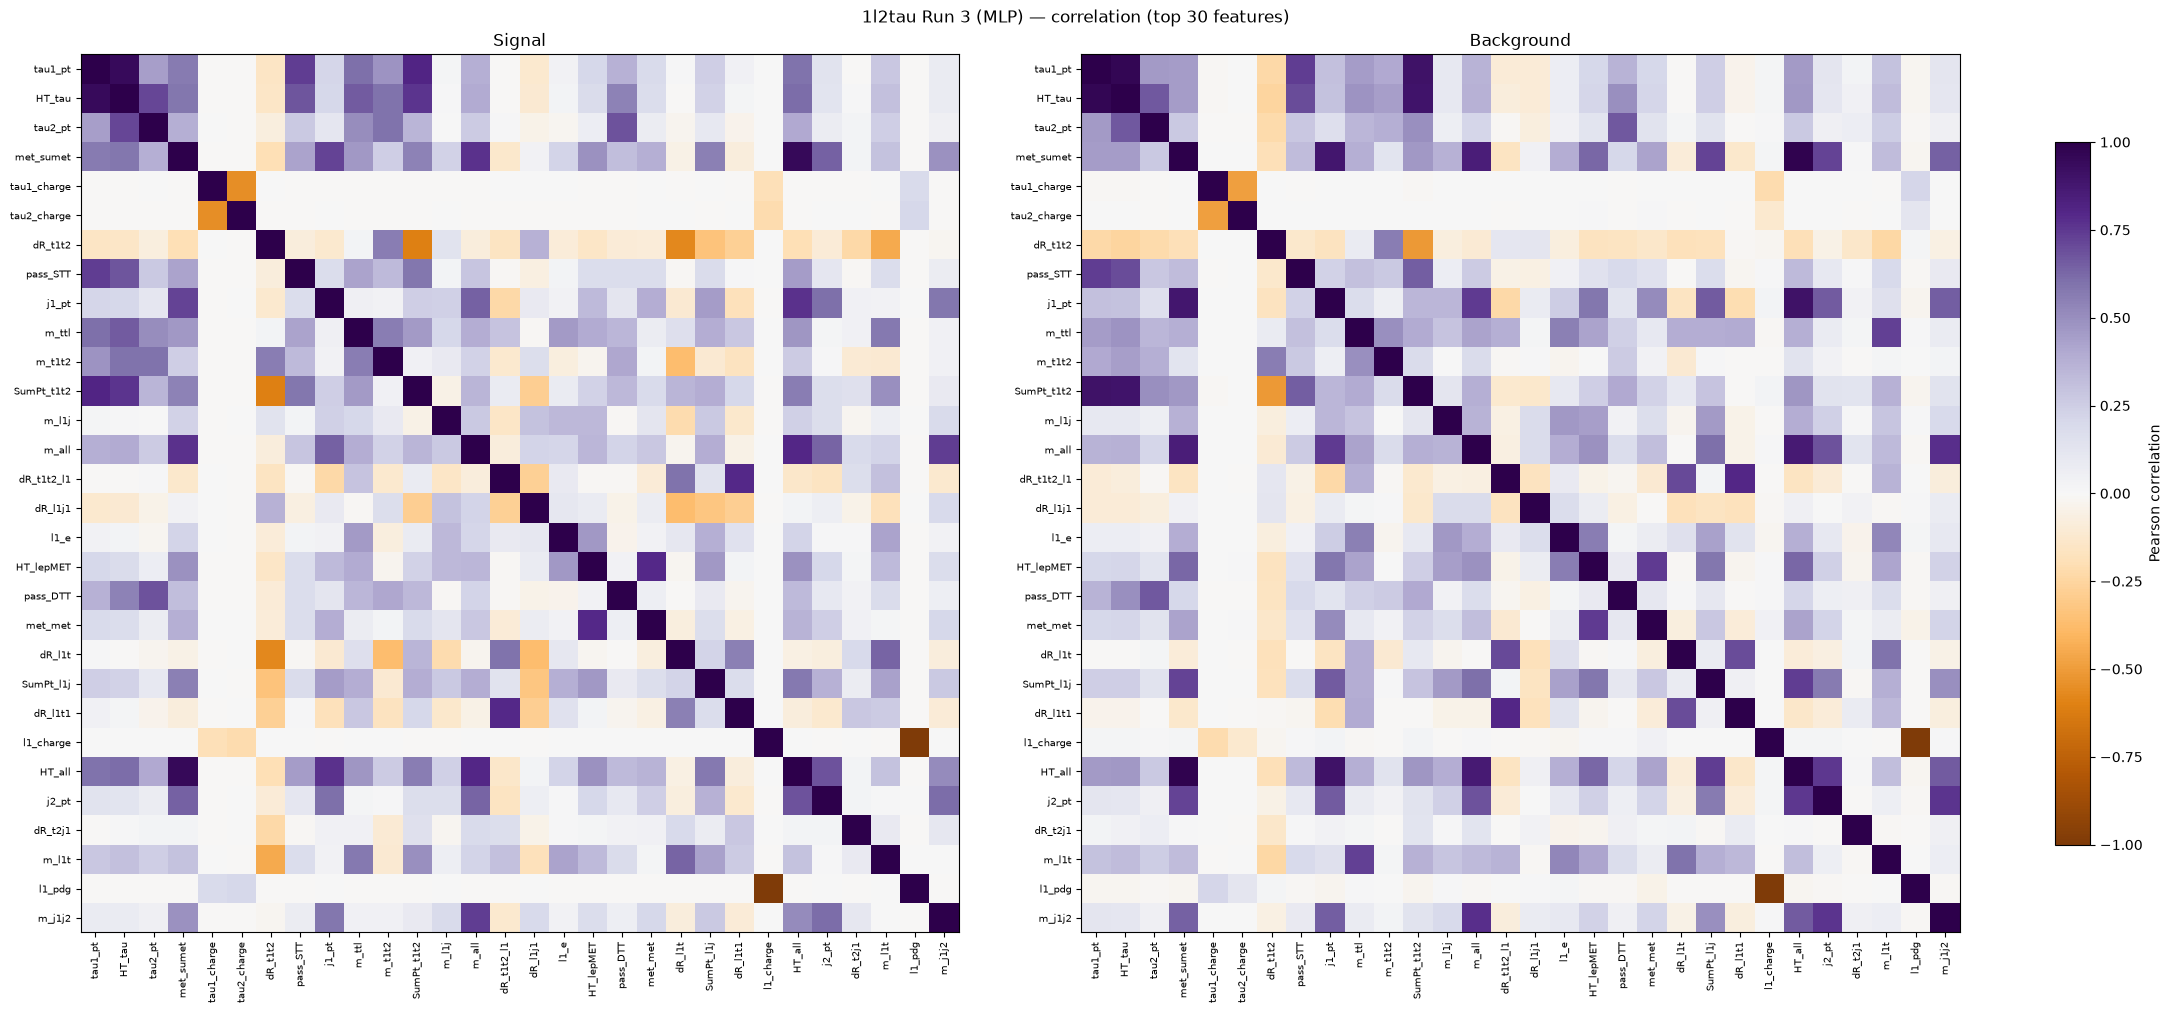

Pairs with |corr| > 0.50 (signal):
l1_charge   l1_pdg        0.996585
met_sumet   HT_all        0.948426
tau1_pt     HT_tau        0.944209
            SumPt_t1t2    0.809316
m_all       HT_all        0.803421
dR_t1t2_l1  dR_l1t1       0.794290
HT_lepMET   met_met       0.792861
met_sumet   m_all         0.768420
j1_pt       HT_all        0.767195
HT_tau      SumPt_t1t2    0.763878
m_all       m_j1j2        0.740129
tau1_pt     pass_STT      0.738444
met_sumet   j1_pt         0.725144
HT_tau      tau2_pt       0.711260

Pairs with |corr| > 0.50 (background):
l1_charge   l1_pdg        0.996572
met_sumet   HT_all        0.979360
tau1_pt     HT_tau        0.967156
            SumPt_t1t2    0.903089
j1_pt       HT_all        0.901840
HT_tau      SumPt_t1t2    0.897660
met_sumet   j1_pt         0.879346
m_all       HT_all        0.864048
met_sumet   m_all         0.850544
dR_t1t2_l1  dR_l1t1       0.797999
m_all       m_j1j2        0.774481
j2_pt       m_j1j2        0.762550
HT_all      j2_

In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_run3 = importance_run3.index[:TOP_N_IMPORTANCE].tolist()
corrs_run3 = grouped_correlations(data_run3, top_feats_run3, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_run3[1], corrs_run3[0]], ["Signal", "Background"], top_feats_run3,
    suptitle=f"1l2tau Run 3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_run3[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_run3[0]).to_string())

In [ ]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------

corr_max_run3 = corrs_run3[1].abs().combine(corrs_run3[0].abs(), np.maximum)
PRUNED_FEATURES_run3, dropped_features_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. tau1_pt
   2. tau2_pt
   3. met_sumet
   4. tau1_charge
   5. tau2_charge
   6. dR_t1t2
   7. pass_STT
   8. m_ttl
   9. m_t1t2
  10. m_l1j
  11. dR_t1t2_l1
  12. dR_l1j1
  13. l1_e
  14. HT_lepMET
  15. pass_DTT
  16. dR_l1t
  17. SumPt_l1j
  18. l1_charge
  19. j2_pt
  20. dR_t2j1

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.879)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  m_all           -> redundant with met_sumet       (|corr| = 0.851)
  met_met         -> redundant with HT_lepMET       (|corr| = 0.793)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  HT_all          -> redundant with met_sumet       (|corr| = 0.979)


Full model      (68 features): train_auc_eval = 0.9533 | val_auc = 0.9470
Pruned model     (20 features): train_auc_eval = 0.9448 | val_auc = 0.9447
Baseline weighted AUC: 0.9447


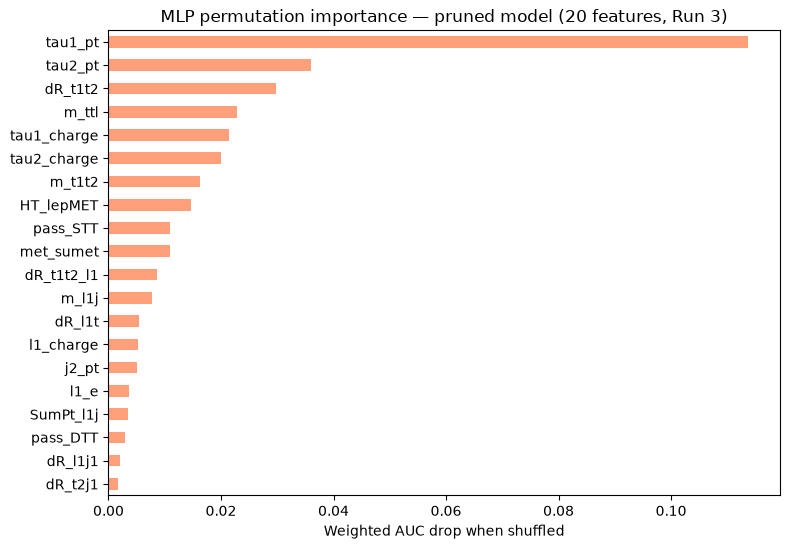

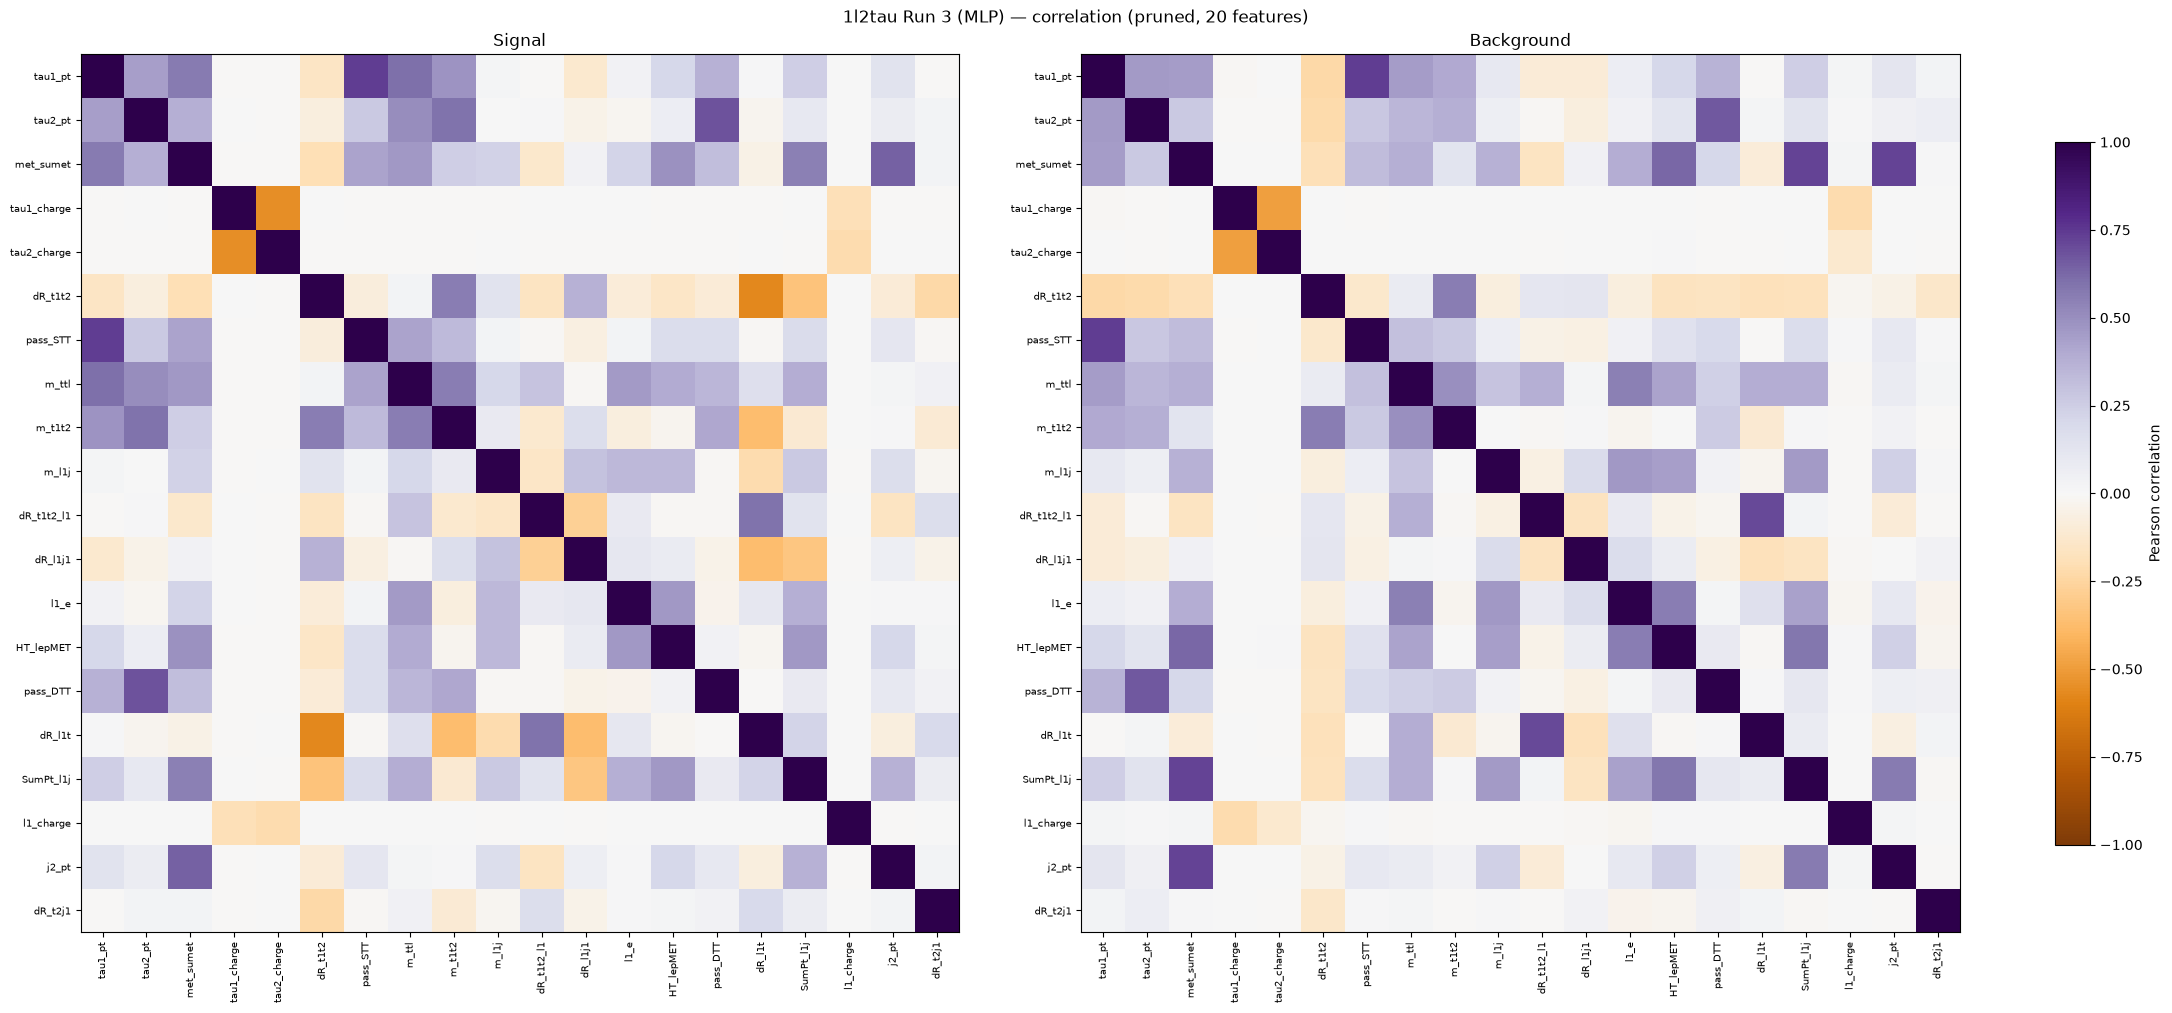

In [ ]:
# ---- Retrain on the pruned feature set --------------------------------
def subset_feature_tensors_run3(feature_subset, all_features=features_run3):

    """
    Run 3 version of subset_feature_tensors: slices the already-scaled Run 3
    train/val numpy arrays (X_train_scaled_run3/X_val_scaled_run3) instead of
    the Run 2 globals, so Run 2's arrays are untouched.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled_run3[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t


X_train_pruned_t_run3, X_val_pruned_t_run3, X_test_pruned_t_run3 = subset_feature_tensors_run3(PRUNED_FEATURES_run3)

model_pruned_run3, history_pruned_run3, val_auc_pruned_run3, train_auc_pruned_run3, train_auc_eval_pruned_run3 = train_model(
    hidden_sizes=best_hidden_sizes_run3, verbose=False,
    X_train_data=X_train_pruned_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_pruned_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

print(f"Full model      ({len(features_run3):2d} features): train_auc_eval = {best_train_auc_eval_run3:.4f} | val_auc = {best_val_auc_run3:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_run3):2d} features): train_auc_eval = {train_auc_eval_pruned_run3:.4f} | val_auc = {val_auc_pruned_run3:.4f}")

importance_pruned_run3 = permutation_importance(model_pruned_run3, X_val_pruned_t_run3, y_val_t_run3, w_val_t_run3, PRUNED_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_pruned_run3, top_n=len(PRUNED_FEATURES_run3),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_run3)} features, Run 3)",
    color="lightsalmon",
)

pruned_corrs_run3 = grouped_correlations(data_run3, PRUNED_FEATURES_run3, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_run3[1], pruned_corrs_run3[0]], ["Signal", "Background"], PRUNED_FEATURES_run3,
    suptitle=f"1l2tau Run 3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_run3)} features)",
)

## Top-15 Features Only — Run 3

Kept 15 decorrelated features (most -> least important):
   1. tau1_pt
   2. tau2_pt
   3. met_sumet
   4. tau1_charge
   5. tau2_charge
   6. dR_t1t2
   7. pass_STT
   8. m_ttl
   9. m_t1t2
  10. m_l1j
  11. dR_t1t2_l1
  12. dR_l1j1
  13. l1_e
  14. HT_lepMET
  15. pass_DTT

Dropped 4 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.879)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  m_all           -> redundant with met_sumet       (|corr| = 0.851)


Baseline weighted AUC: 0.9405


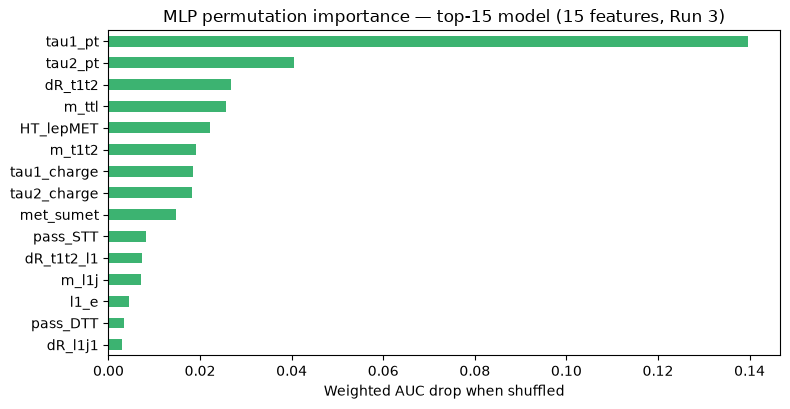


Weighted train(eval-mode)/validation AUC comparison (Run 3):


,model,train_auc_eval,val_auc
0,Full (68 features),0.953275,0.947013
1,Pruned (20 features),0.944774,0.944656
2,Top-15 (15 features),0.940217,0.940481


In [ ]:
TOP15_FEATURES_run3, dropped_top15_run3 = prune_correlated(top_feats_run3, corr_max_run3, CORR_THRESH, n_keep=15)

X_train_top15_t_run3, X_val_top15_t_run3, X_test_top15_t_run3 = subset_feature_tensors_run3(TOP15_FEATURES_run3)

model_top15_run3, history_top15_run3, val_auc_top15_run3, train_auc_top15_run3, train_auc_eval_top15_run3 = train_model(
    hidden_sizes=best_hidden_sizes_run3, verbose=False,
    X_train_data=X_train_top15_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_top15_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

importance_top15_run3 = permutation_importance(model_top15_run3, X_val_top15_t_run3, y_val_t_run3, w_val_t_run3, TOP15_FEATURES_run3, n_repeats=5)
plot_importance_bar(
    importance_top15_run3, top_n=len(TOP15_FEATURES_run3),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_run3)} features, Run 3)",
    color="mediumseagreen",
)

comparison_run3 = pd.DataFrame([
    {"model": f"Full ({len(features_run3)} features)", "train_auc_eval": best_train_auc_eval_run3, "val_auc": best_val_auc_run3},
    {"model": f"Pruned ({len(PRUNED_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_pruned_run3, "val_auc": val_auc_pruned_run3},
    {"model": f"Top-15 ({len(TOP15_FEATURES_run3)} features)", "train_auc_eval": train_auc_eval_top15_run3, "val_auc": val_auc_top15_run3},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Run 3):")
comparison_run3

## Physics Figure of Merit & Final Summary — Run 3

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to Run 3's
held-out TEST partition.


In [ ]:
# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the Run 3 pruning walk above. The score CUT
# is selected here by scanning VAL only - it is applied FROZEN to test in the
# "Held-Out Test Evaluation" cell below, never re-scanned there.
models_registry_run3 = {
    f"Full ({len(features_run3)} features)": (model_run3, X_val_t_run3, X_test_t_run3),
    f"Pruned ({len(PRUNED_FEATURES_run3)} features)": (model_pruned_run3, X_val_pruned_t_run3, X_test_pruned_t_run3),
    f"Top-15 ({len(TOP15_FEATURES_run3)} features)": (model_top15_run3, X_val_top15_t_run3, X_test_top15_t_run3),
}
best_name_run3 = f"Top-15 ({len(TOP15_FEATURES_run3)} features)"

final_model_run3, X_val_final_t_run3, X_test_final_t_run3 = models_registry_run3[best_name_run3]

final_model_run3.eval()
with torch.no_grad():
    val_scores_run3 = torch.sigmoid(final_model_run3(X_val_final_t_run3)).cpu().numpy()

z_val_run3, thr_val_run3 = significance_scan(y_val_run3, val_scores_run3, w_val_run3)  # signed w_phys - expected yields
final_val_auc_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "val_auc"].iloc[0]
final_train_auc_eval_run3 = comparison_run3.loc[comparison_run3["model"] == best_name_run3, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name_run3}")
print(f"Weighted val AUC = {final_val_auc_run3:.4f}")
print(f"Max Asimov Z (val) = {z_val_run3:.3f} at score cut = {thr_val_run3:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9405
Max Asimov Z (val) = 0.023 at score cut = 0.9663


### Held-Out Test Evaluation (Run 3)

`X_test_final_t_run3`/`y_test_run3`/`w_test_run3` have not participated in
anything above. This is the one place they are read: the final model is
scored once, and the VAL-selected score cut is applied frozen.


In [ ]:
# ---- HELD-OUT TEST EVALUATION (Run 3) — scored EXACTLY ONCE ----------------
# X_test_final_t_run3/y_test_run3/w_test_run3 have not been touched anywhere
# above - this is the only cell in the Run 3 section that reads them. The
# score cut `thr_val_run3` was chosen by scanning VAL only; it is applied
# here FROZEN, NOT re-scanned on test.

final_model_run3.eval()
with torch.no_grad():
    test_scores_run3 = torch.sigmoid(final_model_run3(X_test_final_t_run3)).cpu().numpy()

auc_test_run3 = roc_auc_score(y_test_run3, test_scores_run3, sample_weight=w_test_fit_run3)

S_test_run3 = w_test_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 1)].sum()
B_test_run3 = w_test_run3[(test_scores_run3 >= thr_val_run3) & (y_test_run3 == 0)].sum()
z_test_run3 = (np.sqrt(2 * ((S_test_run3 + B_test_run3) * np.log(1 + S_test_run3 / B_test_run3) - S_test_run3))
               if (S_test_run3 > 0 and B_test_run3 > 0) else np.nan)

print(f"Final model: {best_name_run3}")
print(f"Weighted AUC: val = {final_val_auc_run3:.4f}  |  test (held-out, scored once) = {auc_test_run3:.4f}")
print(f"At the VAL-selected score cut = {thr_val_run3:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_run3:.2f} | test B = {B_test_run3:.2f} | test Z = {z_test_run3:.3f}  (val Z was {z_val_run3:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9405  |  test (held-out, scored once) = 0.9420
At the VAL-selected score cut = 0.9663 (frozen, NOT re-scanned on test):
  test S = 0.06 | test B = 6.49 | test Z = 0.025  (val Z was 0.023)


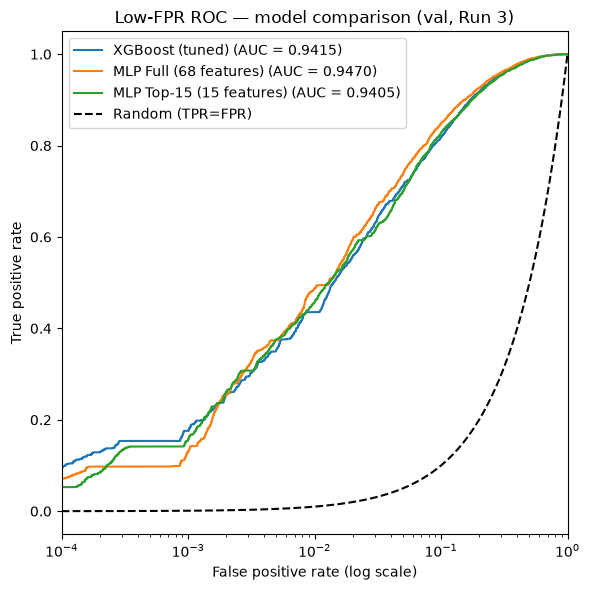

--- FPR = 1e-03 (~112 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.1757  (176x random lift)
  MLP Full (68 features)           TPR = 0.1307  (131x random lift)
  MLP Top-15 (15 features)         TPR = 0.1563  (156x random lift)
--- FPR = 1e-02 (~1120 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4357  (44x random lift)
  MLP Full (68 features)           TPR = 0.4877  (49x random lift)
  MLP Top-15 (15 features)         TPR = 0.4568  (46x random lift)


In [ ]:
# ---- Load the tuned XGBoost model for the same 1l2tau Run 3 track, for an
# apples-to-apples overlay. val_df_run3 here is Run 3's own holdout split.

import xgboost as xgb

xgb_model_run3 = xgb.XGBClassifier()
xgb_model_run3.load_model(BASE_DIR_RUN3 / "final_model_run3.json")
with open(BASE_DIR_RUN3 / "optuna_features_run3.json") as f:
    xgb_features_run3 = json.load(f)

xgb_val_scores_run3 = xgb_model_run3.predict_proba(val_df_run3[xgb_features_run3])[:, 1]

# ROC curve for the FINAL model (top-15 pruned, `val_scores_run3` from the
# significance-scan cell above), not the full model - matches the `best_name_run3` label.
fpr_val_run3, tpr_val_run3, _ = roc_curve(y_val_run3, val_scores_run3, sample_weight=w_val_fit_run3)

curves_run3 = {
    "XGBoost (tuned)": roc_with_auc(y_val_run3, xgb_val_scores_run3, w_val_fit_run3),
    f"MLP Full ({len(features_run3)} features)": roc_with_auc(y_val_run3, val_probs_run3, w_val_fit_run3),
    f"MLP {best_name_run3}": (fpr_val_run3, tpr_val_run3, final_val_auc_run3),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_run3.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Run 3)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_run3 = int((y_val_run3 == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_run3:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_run3.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert np.isfinite(X_train_scaled_run3).all() and np.isfinite(X_val_scaled_run3).all() and np.isfinite(X_test_scaled_run3).all(), \
    "NaN/inf reached the model input (Run 3)"

# Determinism check, same convention as the Run 2 section.
set_seed(RANDOM_STATE)
_, _, det_check_a_run3, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_run3, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_run3, y_train_data=y_train_t_run3, w_train_data=w_train_t_run3,
    X_val_data=X_val_t_run3, y_val_data=y_val_t_run3, w_val_data=w_val_t_run3,
    w_train_eval_data=w_train_abs_t_run3,
)
assert det_check_a_run3 == det_check_b_run3, f"Determinism check FAILED: {det_check_a_run3} != {det_check_b_run3}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_run3:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test_run3, z_test_run3 at the
# frozen, VAL-selected score cut).

summary_run3 = pd.DataFrame([{
    "model": best_name_run3,
    "train_auc_eval": final_train_auc_eval_run3,
    "val_auc": final_val_auc_run3,
    "max_asimov_Z (val)": z_val_run3,
    "test_auc (held-out, scored once)": auc_test_run3,
    "test_Z_at_val_cut (held-out)": z_test_run3,
}])

print("\nFinal summary (MLP, 1l2tau Run 3):")
print(summary_run3.to_string(index=False))
summary_run3


Determinism check passed: two re-seeded runs give identical val_auc = 0.904923

Final summary (MLP, 1l2tau Run 3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.940217 0.940481            0.023411                          0.941993                      0.024854


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.940217,0.940481,0.023411,0.941993,0.024854


## Run 2 + Run 3 — Combined Track

Chains (concatenates) Run 2 and Run 3 events into a single training sample,
mirroring `1L2Tau_Master_Pipeline.ipynb`'s Section 5. The candidate feature
set is restricted to branches common to BOTH runs (the intersection of
`features_run2` and `features_run3`, equivalent to discovering common
branches across all process files in both directories). An extra `run`
bookkeeping column (2 or 3) is kept (never a training feature) so the
Run2/Run3 mix can be checked, and so the train/val split can be stratified
on `label` AND `run` jointly. Everything below uses `_comb`-suffixed
variable names so the Run 2 and Run 3 results above remain untouched.

In [ ]:
# Combined uses features common to BOTH runs (equivalent to discovering
# common branches across all process files in both directories).

candidate_features_comb = sorted(set(features_run2) & set(features_run3))

keep_cols_comb = candidate_features_comb + ["w_phys", "label", "process"]

data_run2_tagged = data_run2[keep_cols_comb].copy()
data_run2_tagged["run"] = 2

data_run3_tagged = data_run3[keep_cols_comb].copy()
data_run3_tagged["run"] = 3

data_comb_raw = pd.concat([data_run2_tagged, data_run3_tagged], ignore_index=True)
data_comb, features_comb = clean_data(data_comb_raw, candidate_features_comb)

print(f"\nCombined: {len(data_comb)} events, {len(features_comb)} features "
      f"(intersection of Run2's {len(features_run2)} and Run3's {len(features_run3)})")

for run_label in (2, 3):
    sub = data_comb[data_comb["run"] == run_label]
    print(f"Run {run_label}: signal yield = {sub.loc[sub.label==1,'w_phys'].sum():.2f} | "
          f"background yield = {sub.loc[sub.label==0,'w_phys'].sum():.2f} | n_events = {len(sub)}")

Dropped 0 constant/empty features:
  []

68 final features
Total: 2015576 events | signal = 293764 | background = 1721812
Yield (w_phys): signal = 3.91 | background = 30834.21

Combined: 2015576 events, 68 features (intersection of Run2's 68 and Run3's 68)
Run 2: signal yield = 1.82 | background yield = 11467.29 | n_events = 690684
Run 3: signal yield = 2.08 | background yield = 19366.92 | n_events = 1324892


## Sentinel Audit (-1) — Combined

Same diagnostic as the Run 2/Run 3 sections above, run on the combined
sample.

In [ ]:
NEG1_SENTINEL_FEATURES_comb = set()

neg1_rows_comb = []
for f in features_comb:
    vals = data_comb[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows_comb.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df_comb = pd.DataFrame(neg1_rows_comb).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df_comb)} / {len(features_comb)} features have at least one row exactly equal to -1:")
print(neg1_df_comb.to_string(index=False))

for f in NEG1_SENTINEL_FEATURES_comb:
    data_comb[f] = data_comb[f].mask(data_comb[f] == -1)
if NEG1_SENTINEL_FEATURES_comb:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES_comb)}")
else:
    print("\nNEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.")

3 / 68 features have at least one row exactly equal to -1:
    feature  frac_exactly_-1  gap_to_next_value_above
tau1_charge         0.495344                      2.0
tau2_charge         0.488802                      2.0
  l1_charge         0.474537                      2.0

NEG1_SENTINEL_FEATURES_comb is empty - no -1 values masked.


## Train/Validation/Test Split & Preprocessing — Combined

Same 80/10/10 `make_3way_split`, but stratified on `label` AND `run` jointly
(not just `label`) so all three partitions keep the same Run2/Run3 mix -
passed via `extra_stratify_col="run"`. TEST is held out (persisted + never
used for imputation/scaling/pruning/tuning/early stopping) the same way as
the Run 2/Run 3 sections. Preprocessing (median imputation, standard
scaling, `__isnan` flags) otherwise follows the same convention.


In [ ]:
train_df_comb, val_df_comb, test_df_comb = make_3way_split(data_comb, extra_stratify_col="run")

BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")
SPLIT_DIR_COMB = BASE_DIR_COMB / "splits"
persist_test_partition(test_df_comb, SPLIT_DIR_COMB)

X_train_raw_comb, y_train_comb, w_train_comb = train_df_comb[features_comb], train_df_comb["label"].to_numpy(), train_df_comb["w_phys"].to_numpy()
X_val_raw_comb,   y_val_comb,   w_val_comb   = val_df_comb[features_comb],   val_df_comb["label"].to_numpy(),   val_df_comb["w_phys"].to_numpy()
X_test_raw_comb,  y_test_comb,  w_test_comb  = test_df_comb[features_comb],  test_df_comb["label"].to_numpy(),  test_df_comb["w_phys"].to_numpy()

# ---- Missingness indicator flags (schema derived from TRAIN only) ---------
nan_train_comb = X_train_raw_comb.isna()
flag_cols_comb = nan_train_comb.columns[nan_train_comb.any()].tolist()


def make_flags_comb(X_raw):
    """Combined-track version of make_flags: 0/1 missingness flags for `flag_cols_comb`."""
    f = X_raw[flag_cols_comb].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols_comb]
    return f


# Median imputation (fit on train only), then standard scaling (fit on train
# only). TEST is only ever transformed with these already-frozen train
# statistics, never used to fit them.

train_medians_comb = X_train_raw_comb.median()
X_train_imp_comb = X_train_raw_comb.fillna(train_medians_comb)
X_val_imp_comb = X_val_raw_comb.fillna(train_medians_comb)
X_test_imp_comb = X_test_raw_comb.fillna(train_medians_comb)

scaler_comb = StandardScaler()
X_train_scaled_comb = np.hstack([scaler_comb.fit_transform(X_train_imp_comb), make_flags_comb(X_train_raw_comb).to_numpy()])
X_val_scaled_comb = np.hstack([scaler_comb.transform(X_val_imp_comb), make_flags_comb(X_val_raw_comb).to_numpy()])
X_test_scaled_comb = np.hstack([scaler_comb.transform(X_test_imp_comb), make_flags_comb(X_test_raw_comb).to_numpy()])

assert np.isfinite(X_train_scaled_comb).all(), "NaN/inf reached the model input (train, Combined)"
assert np.isfinite(X_val_scaled_comb).all(), "NaN/inf reached the model input (val, Combined)"
assert np.isfinite(X_test_scaled_comb).all(), "NaN/inf reached the model input (test, Combined)"

print(f"\n{len(flag_cols_comb)} features had missing values in train -> added {len(flag_cols_comb)} __isnan flag "
      f"columns (final input width = {X_train_scaled_comb.shape[1]} = {len(features_comb)} features + {len(flag_cols_comb)} flags)")

# Training weights: |w_phys|, class-balanced + mean-normalized.
w_train_fit_comb = make_fit_weights(y_train_comb, np.abs(w_train_comb))
w_train_abs_comb = np.abs(w_train_comb)  # unweighted-balance version, for eval-mode "comparable" train curves

# Validation weights for AUC: plain |w_phys| so AUC reflects the true class balance.
w_val_fit_comb = np.abs(w_val_comb)

# Test weights: plain |w_phys| too - test is only ever scored once, at the
# very end.
w_test_fit_comb = np.abs(w_test_comb)

print(f"Signal weight scale factor (train): "
      f"{np.abs(w_train_comb[y_train_comb==0]).sum() / np.abs(w_train_comb[y_train_comb==1]).sum():.1f}")


Train:  1612460 events | signal =  235011 (yield=      3.13) | background = 1377449 (yield=  24677.47) | signal weight scale factor = 7886.8
       run mix: {2: 552547, 3: 1059913}
Val  :   201558 events | signal =   29377 (yield=      0.39) | background =  172181 (yield=   3213.90) | signal weight scale factor = 8315.5
       run mix: {2: 69069, 3: 132489}
Test :   201558 events | signal =   29376 (yield=      0.39) | background =  172182 (yield=   2942.84) | signal weight scale factor = 7548.5
       run mix: {2: 69068, 3: 132490}
  cross-check OK: PPSSP_2026/1l2tau/combined/splits/test.root test partition matches on 71 shared columns (201558 rows)
Wrote 201558 test events -> PPSSP_2026/1l2tau/combined/splits/test.root  (held out until final evaluation)

0 features had missing values in train -> added 0 __isnan flag columns (final input width = 68 = 68 features + 0 flags)
Signal weight scale factor (train): 10813.0


## PyTorch Dataset & Model — Combined

In [ ]:
X_train_t_comb = torch.tensor(X_train_scaled_comb, dtype=torch.float32, device=DEVICE)
y_train_t_comb = torch.tensor(y_train_comb, dtype=torch.float32, device=DEVICE)
w_train_t_comb = torch.tensor(w_train_fit_comb, dtype=torch.float32, device=DEVICE)
w_train_abs_t_comb = torch.tensor(w_train_abs_comb, dtype=torch.float32, device=DEVICE)  # |w_phys|, dropout-off "eval-mode" train weights

X_val_t_comb = torch.tensor(X_val_scaled_comb, dtype=torch.float32, device=DEVICE)
y_val_t_comb = torch.tensor(y_val_comb, dtype=torch.float32, device=DEVICE)
w_val_t_comb = torch.tensor(w_val_fit_comb, dtype=torch.float32, device=DEVICE)

# TEST is only ever read once, in the "Held-Out Test Evaluation" cell at the
# end of this section.
X_test_t_comb = torch.tensor(X_test_scaled_comb, dtype=torch.float32, device=DEVICE)
y_test_t_comb = torch.tensor(y_test_comb, dtype=torch.float32, device=DEVICE)
w_test_t_comb = torch.tensor(w_test_fit_comb, dtype=torch.float32, device=DEVICE)

model_comb = build_model(n_features=X_train_scaled_comb.shape[1])

print(model_comb)


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=68, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=128, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=64, out_features=32, bias=True)
    (16): ReLU()
    (17): Dropout(p=0.3, inplace=False)
    (18): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Training Loop — Combined

Reuses the same `train_model`/`run_epoch` functions defined in the Run 2
section above, with explicit `_comb` tensors passed in so the Run 2/Run 3
models/histories are untouched.

In [ ]:
model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = train_model(
    hidden_sizes=DEFAULT_HIDDEN_SIZES,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

print(f"\nBest val_auc = {best_val_auc_comb:.4f} | train_auc (dropout on) = {best_train_auc_comb:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval_comb:.4f}")

Epoch   1 | train_loss=0.4375 val_loss=0.3311 | train_auc=0.8851 train_auc_eval=0.9225 val_auc=0.9238
Epoch   2 | train_loss=0.3798 val_loss=0.2970 | train_auc=0.9166 train_auc_eval=0.9318 val_auc=0.9322
Epoch   3 | train_loss=0.3503 val_loss=0.2903 | train_auc=0.9254 train_auc_eval=0.9374 val_auc=0.9356
Epoch   4 | train_loss=0.3414 val_loss=0.3470 | train_auc=0.9292 train_auc_eval=0.9404 val_auc=0.9381
Epoch   5 | train_loss=0.3329 val_loss=0.3585 | train_auc=0.9327 train_auc_eval=0.9430 val_auc=0.9397
Epoch   6 | train_loss=0.3309 val_loss=0.3041 | train_auc=0.9335 train_auc_eval=0.9445 val_auc=0.9414
Epoch   7 | train_loss=0.3306 val_loss=0.3128 | train_auc=0.9339 train_auc_eval=0.9452 val_auc=0.9421
Epoch   8 | train_loss=0.3216 val_loss=0.2961 | train_auc=0.9372 train_auc_eval=0.9460 val_auc=0.9425
Epoch   9 | train_loss=0.3185 val_loss=0.3138 | train_auc=0.9384 train_auc_eval=0.9481 val_auc=0.9438
Epoch  10 | train_loss=0.3165 val_loss=0.2878 | train_auc=0.9392 train_auc_eval=0.

## Simple Hyperparameter Search (hidden layer sizes) — Combined

In [ ]:
search_results_comb = []
best_search_auc_comb, best_hidden_sizes_comb = -np.inf, None

for hidden_sizes in HIDDEN_SIZE_OPTIONS:

    trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval = train_model(
        hidden_sizes=hidden_sizes, verbose=False,
        X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
        X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
        w_train_eval_data=w_train_abs_t_comb,
    )
    search_results_comb.append({"hidden_sizes": hidden_sizes, "train_auc": trial_train_auc, "val_auc": trial_val_auc})
    
    print(f"hidden_sizes={hidden_sizes!s:16s} -> train_auc={trial_train_auc:.4f} val_auc={trial_val_auc:.4f}")

    if trial_val_auc > best_search_auc_comb:
        best_search_auc_comb, best_hidden_sizes_comb = trial_val_auc, hidden_sizes
        model_comb, history_comb, best_val_auc_comb, best_train_auc_comb, best_train_auc_eval_comb = (
            trial_model, trial_history, trial_val_auc, trial_train_auc, trial_train_auc_eval
        )

print(f"\nBest architecture: hidden_sizes={best_hidden_sizes_comb} | val_auc={best_search_auc_comb:.4f}")

hidden_sizes=(64,)            -> train_auc=0.9338 val_auc=0.9383
hidden_sizes=(128, 64)        -> train_auc=0.9401 val_auc=0.9435
hidden_sizes=(256, 128)       -> train_auc=0.9450 val_auc=0.9462
hidden_sizes=(128, 64, 32)    -> train_auc=0.9392 val_auc=0.9433
hidden_sizes=(256, 128, 64, 32) -> train_auc=0.9435 val_auc=0.9458

Best architecture: hidden_sizes=(256, 128) | val_auc=0.9462


## Evaluation — Combined

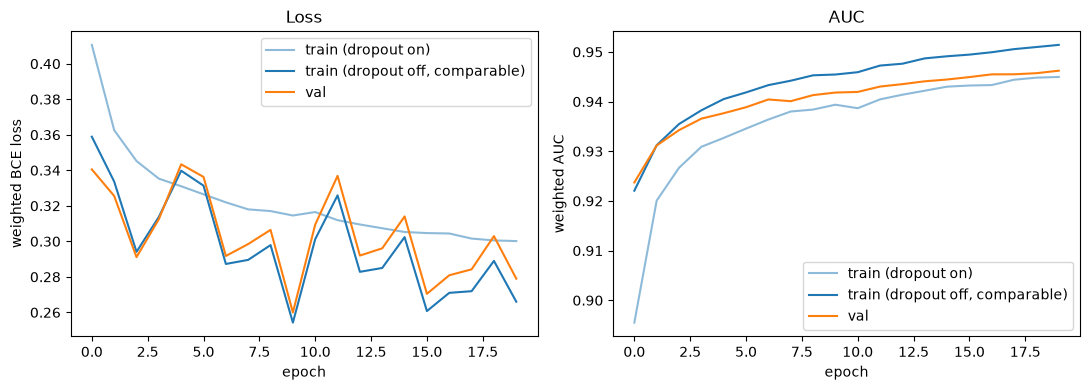

Final weighted AUC: train=0.9514 val=0.9462


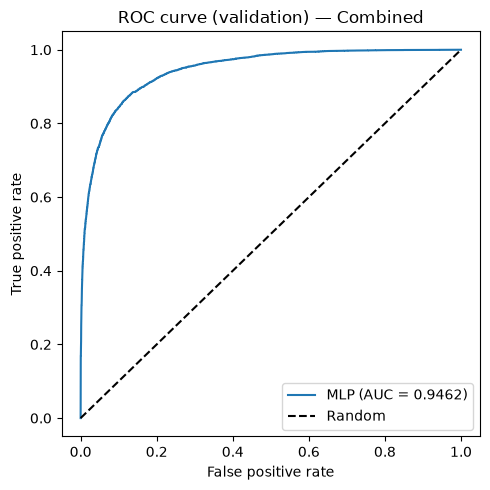

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_comb["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history_comb["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history_comb["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_comb["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history_comb["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history_comb["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

model_comb.eval()
with torch.no_grad():
    train_probs_comb = torch.sigmoid(model_comb(X_train_t_comb)).cpu().numpy()
    val_probs_comb = torch.sigmoid(model_comb(X_val_t_comb)).cpu().numpy()

auc_train_comb = roc_auc_score(y_train_comb, train_probs_comb, sample_weight=np.abs(w_train_comb))
auc_val_comb = roc_auc_score(y_val_comb, val_probs_comb, sample_weight=w_val_fit_comb)

print(f"Final weighted AUC: train={auc_train_comb:.4f} val={auc_val_comb:.4f}")

fpr_comb, tpr_comb, _ = roc_curve(y_val_comb, val_probs_comb, sample_weight=w_val_fit_comb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_comb, tpr_comb, label=f"MLP (AUC = {auc_val_comb:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation) — Combined")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance (Permutation) — Combined

Reuses the same `permutation_importance`/`plot_importance_bar` helpers
defined in the Run 2 section.

Baseline weighted AUC: 0.9462


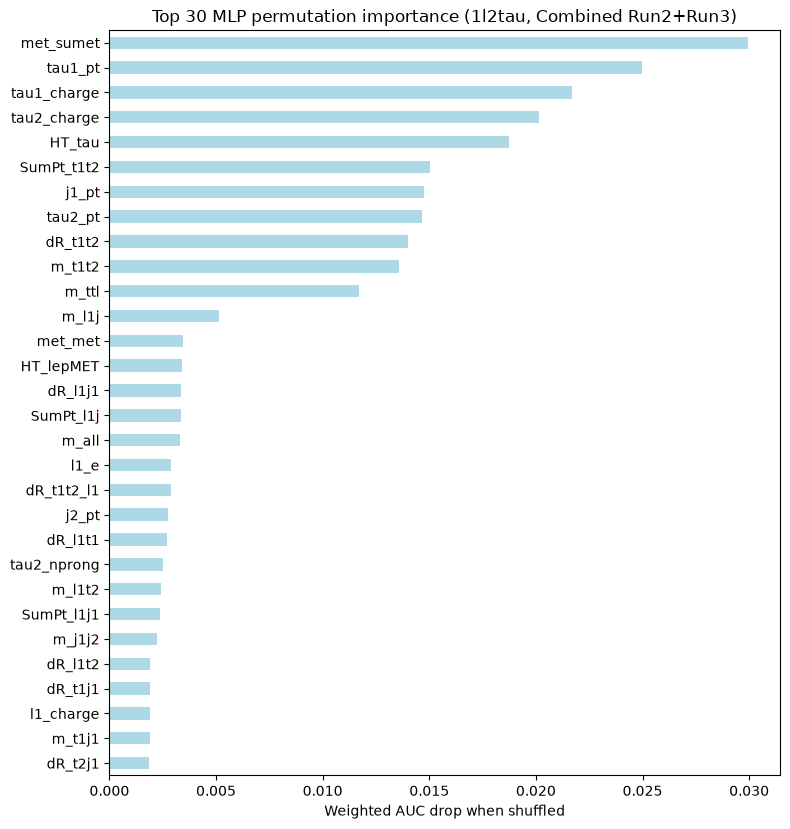

met_sumet      0.029948
tau1_pt        0.024955
tau1_charge    0.021669
tau2_charge    0.020152
HT_tau         0.018739
SumPt_t1t2     0.015019
j1_pt          0.014735
tau2_pt        0.014638
dR_t1t2        0.013991
m_t1t2         0.013584
m_ttl          0.011703
m_l1j          0.005141
met_met        0.003445
HT_lepMET      0.003427
dR_l1j1        0.003366
Name: auc_drop, dtype: float64

In [ ]:
importance_comb = permutation_importance(model_comb, X_val_t_comb, y_val_t_comb, w_val_t_comb, features_comb, n_repeats=5)
plot_importance_bar(importance_comb, top_n=30, title="Top 30 MLP permutation importance (1l2tau, Combined Run2+Run3)")
importance_comb.head(15)

## Correlation Pruning & Retraining — Combined

Reuses `top_pairs`/`grouped_correlations`/`plot_group_correlations`/
`prune_correlated` from the Run 2 section (they take `data`/features as
plain arguments, so they work unchanged on the combined inputs).

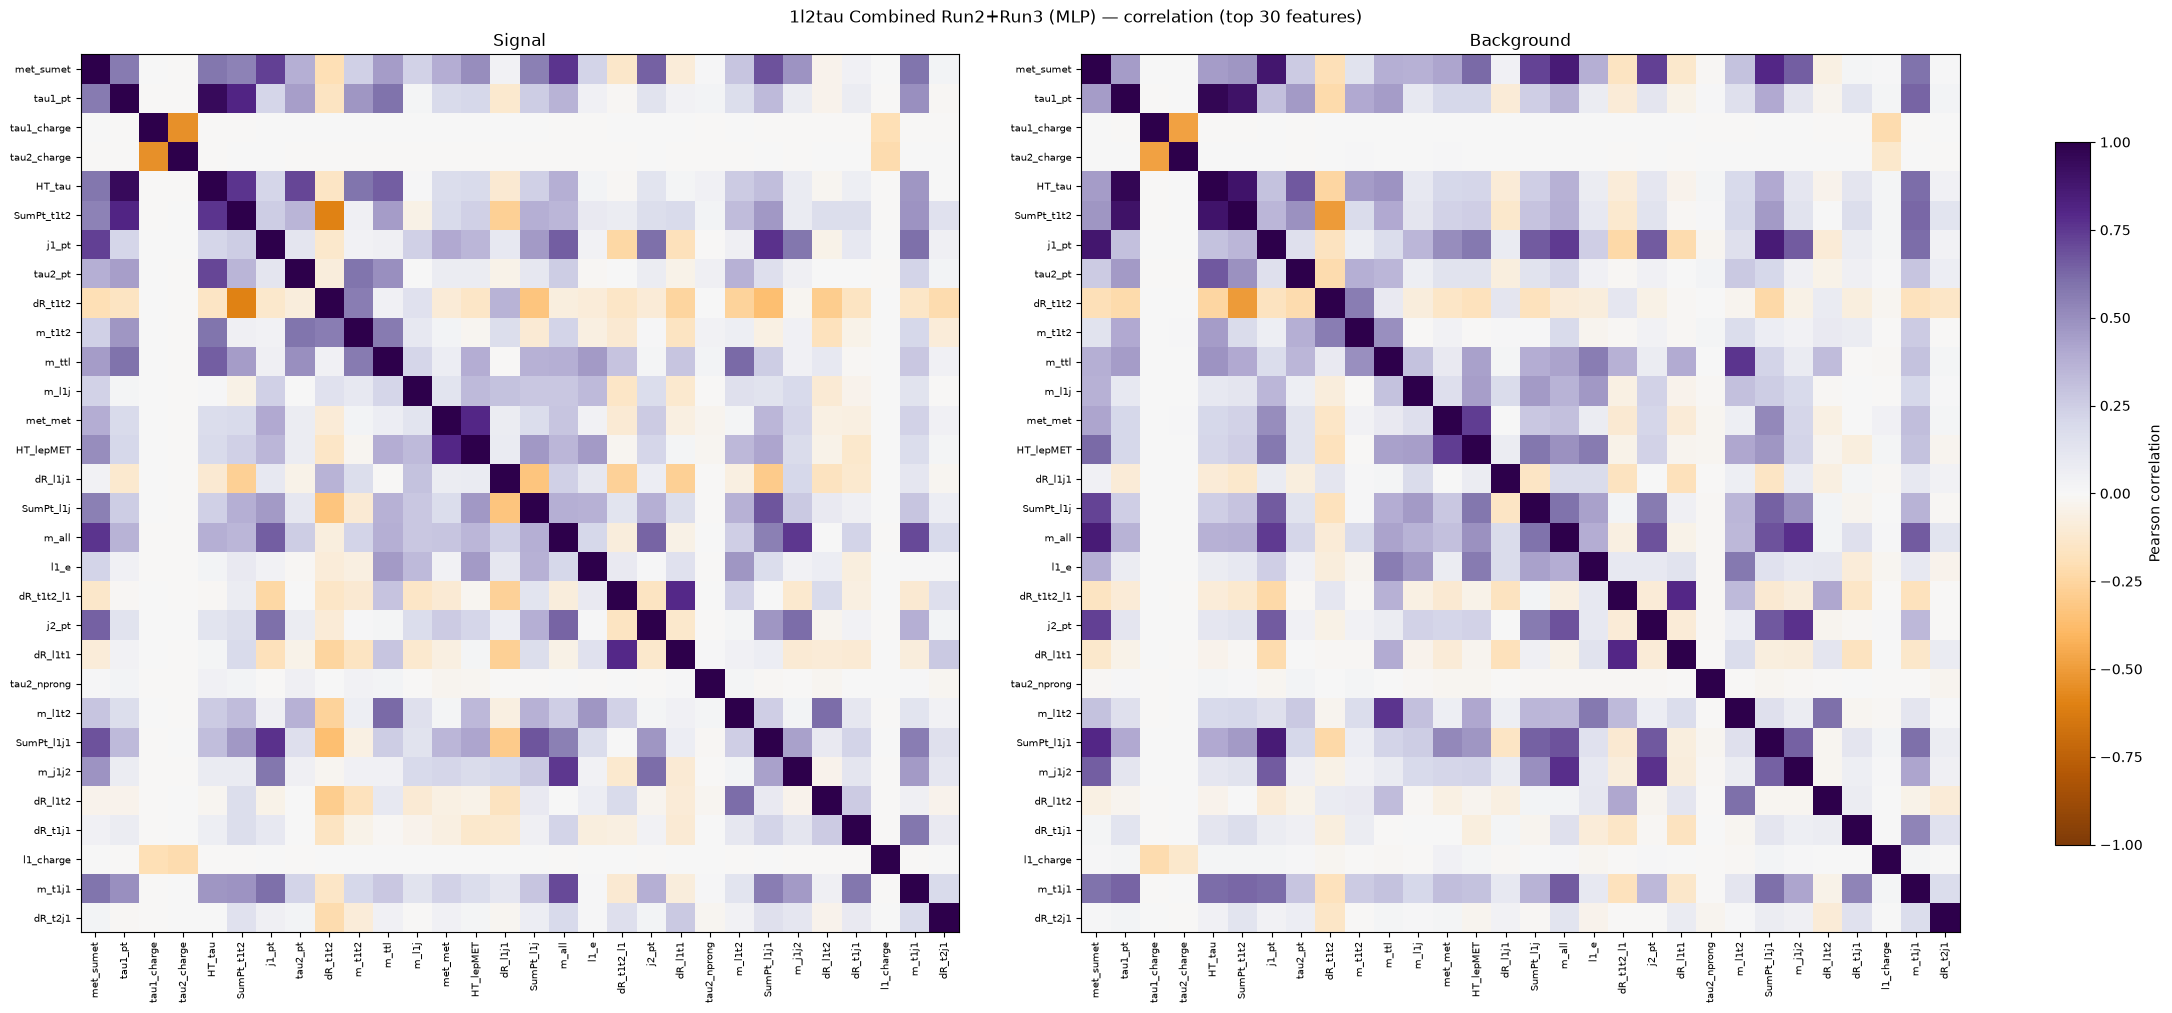

Pairs with |corr| > 0.50 (signal):
tau1_pt     HT_tau        0.944697
            SumPt_t1t2    0.810478
met_met     HT_lepMET     0.797994
dR_t1t2_l1  dR_l1t1       0.794381
j1_pt       SumPt_l1j1    0.768729
HT_tau      SumPt_t1t2    0.765479
met_sumet   m_all         0.758895
m_all       m_j1j2        0.751064
met_sumet   j1_pt         0.733829
HT_tau      tau2_pt       0.712720
m_all       m_t1j1        0.707748

Pairs with |corr| > 0.50 (background):
tau1_pt     HT_tau        0.967221
            SumPt_t1t2    0.903165
HT_tau      SumPt_t1t2    0.896634
met_sumet   j1_pt         0.880292
j1_pt       SumPt_l1j1    0.857840
met_sumet   m_all         0.853706
dR_t1t2_l1  dR_l1t1       0.798178
met_sumet   SumPt_l1j1    0.797188
m_all       m_j1j2        0.775025
j2_pt       m_j1j2        0.768742
m_ttl       m_l1t2        0.760815
j1_pt       m_all         0.748804
met_met     HT_lepMET     0.741907
met_sumet   j2_pt         0.730092
            SumPt_l1j     0.723454


In [ ]:
# ---- Correlation of the top-30 permutation-important features -------------
top_feats_comb = importance_comb.index[:TOP_N_IMPORTANCE].tolist()
corrs_comb = grouped_correlations(data_comb, top_feats_comb, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs_comb[1], corrs_comb[0]], ["Signal", "Background"], top_feats_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (MLP) — correlation (top {TOP_N_IMPORTANCE} features)",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs_comb[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs_comb[0]).to_string())

In [ ]:
# ---- Correlation-based pruning to a decorrelated top-20 --------------------
corr_max_comb = corrs_comb[1].abs().combine(corrs_comb[0].abs(), np.maximum)
PRUNED_FEATURES_comb, dropped_features_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, N_KEEP)

Kept 20 decorrelated features (most -> least important):
   1. met_sumet
   2. tau1_pt
   3. tau1_charge
   4. tau2_charge
   5. tau2_pt
   6. dR_t1t2
   7. m_t1t2
   8. m_ttl
   9. m_l1j
  10. met_met
  11. dR_l1j1
  12. SumPt_l1j
  13. l1_e
  14. dR_t1t2_l1
  15. j2_pt
  16. tau2_nprong
  17. dR_l1t2
  18. dR_t1j1
  19. l1_charge
  20. m_t1j1

Dropped 9 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.798)
  m_l1t2          -> redundant with m_ttl           (|corr| = 0.761)
  SumPt_l1j1      -> redundant with met_sumet       (|corr| = 0.797)
  m_j1j2          -> red

Full model      (68 features): train_auc_eval = 0.9514 | val_auc = 0.9462
Pruned model     (20 features): train_auc_eval = 0.9442 | val_auc = 0.9417
Baseline weighted AUC: 0.9417


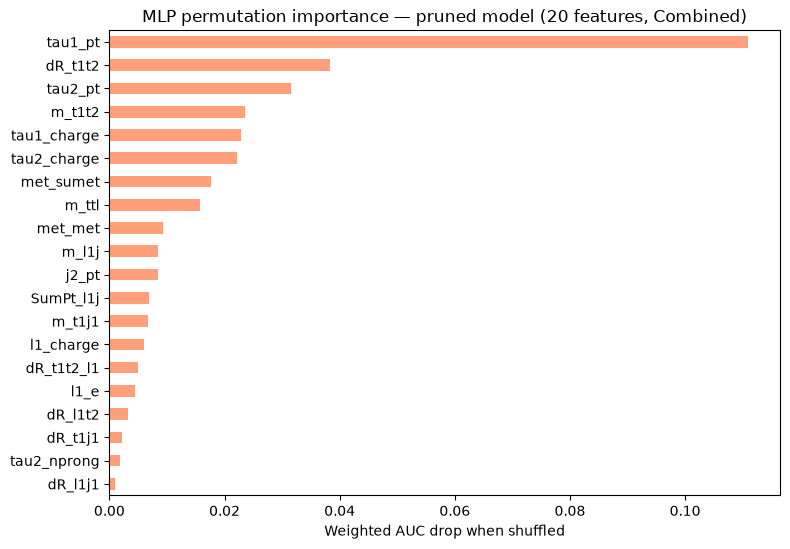

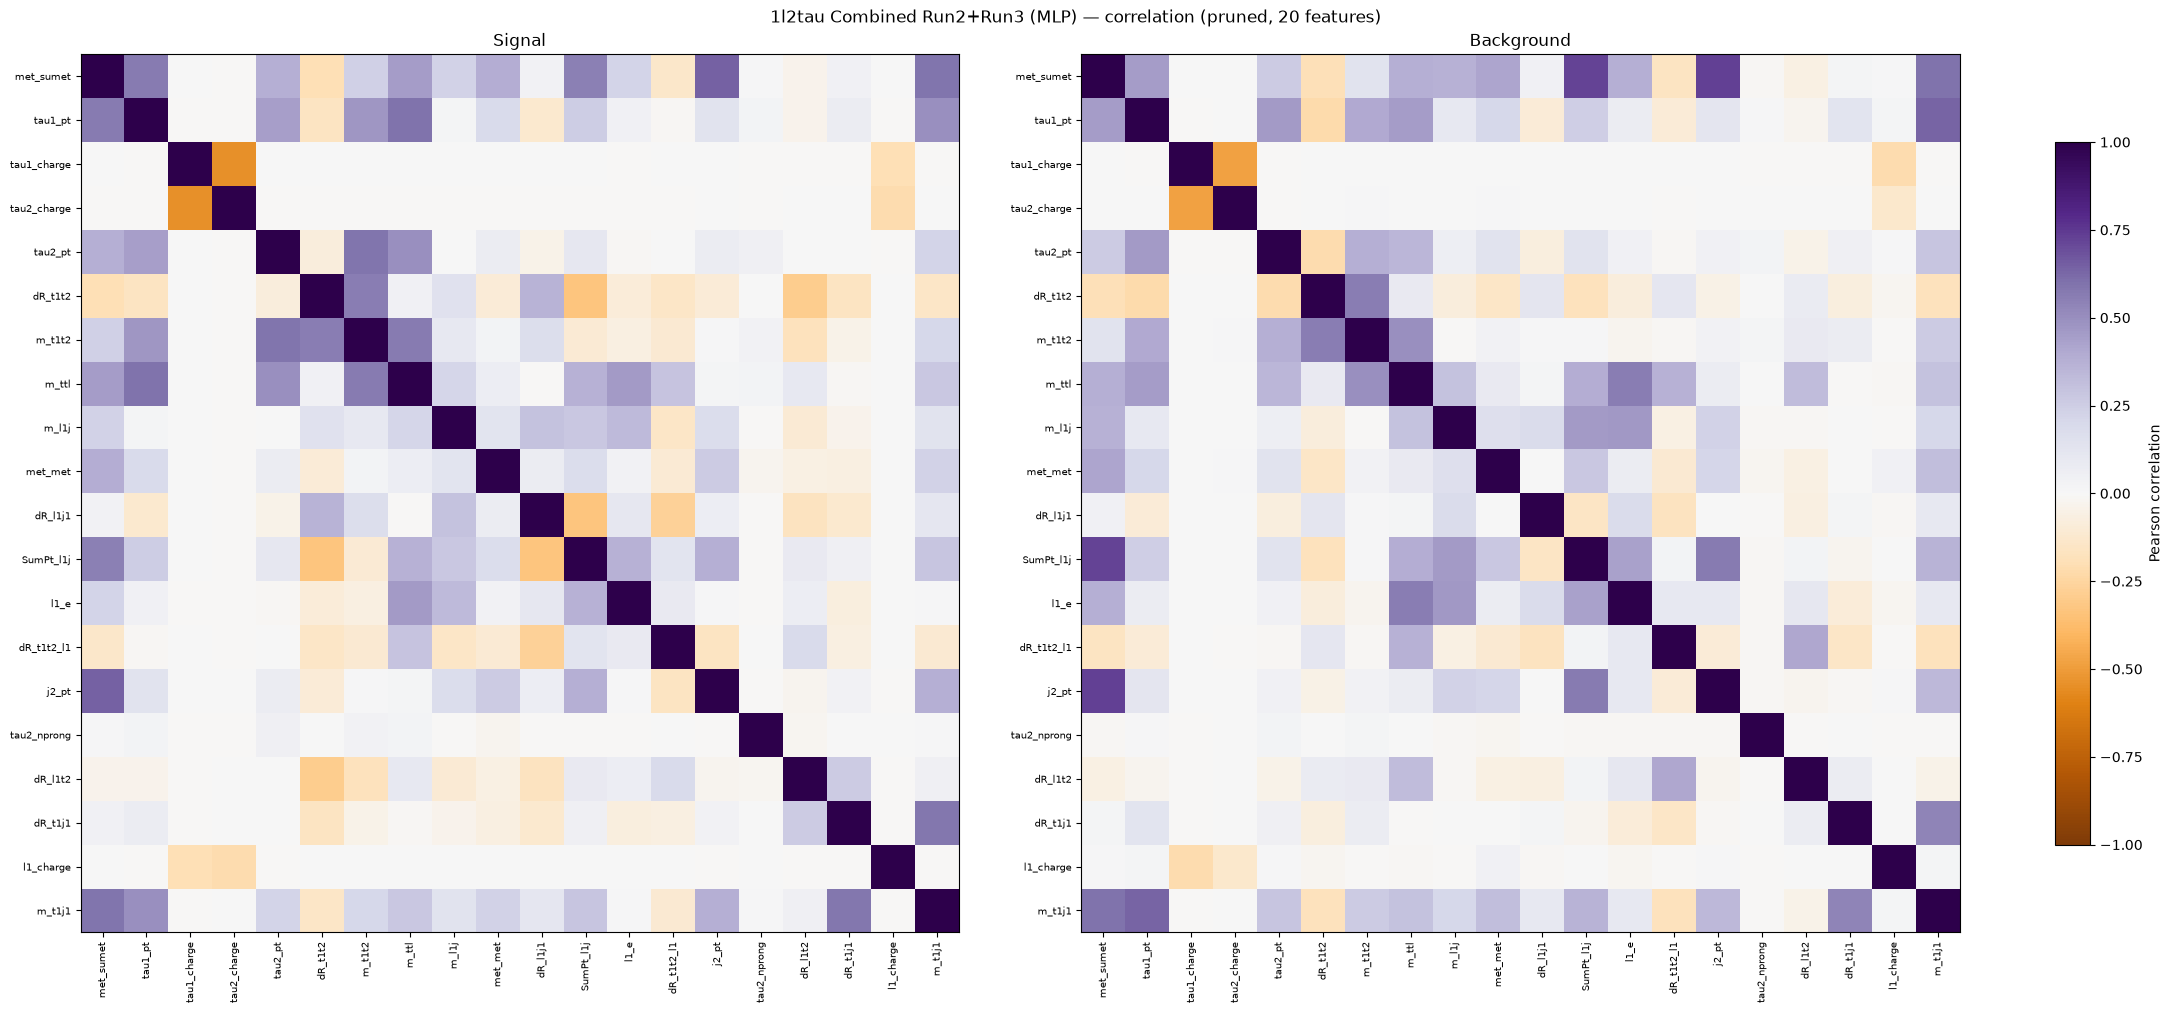

In [ ]:
# ---- Retrain on the pruned feature set --------------------------------
def subset_feature_tensors_comb(feature_subset, all_features=features_comb):

    """
    Combined-track version of subset_feature_tensors: slices the
    already-scaled Combined train/val/test numpy arrays (X_train_scaled_comb/
    X_val_scaled_comb/X_test_scaled_comb) instead of the Run 2/Run 3 globals.
    """

    idx = [all_features.index(f) for f in feature_subset]
    X_train_sub_t = torch.tensor(X_train_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    X_val_sub_t = torch.tensor(X_val_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    X_test_sub_t = torch.tensor(X_test_scaled_comb[:, idx], dtype=torch.float32, device=DEVICE)
    return X_train_sub_t, X_val_sub_t, X_test_sub_t


X_train_pruned_t_comb, X_val_pruned_t_comb, X_test_pruned_t_comb = subset_feature_tensors_comb(PRUNED_FEATURES_comb)

model_pruned_comb, history_pruned_comb, val_auc_pruned_comb, train_auc_pruned_comb, train_auc_eval_pruned_comb = train_model(
    hidden_sizes=best_hidden_sizes_comb, verbose=False,
    X_train_data=X_train_pruned_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_pruned_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

print(f"Full model      ({len(features_comb):2d} features): train_auc_eval = {best_train_auc_eval_comb:.4f} | val_auc = {best_val_auc_comb:.4f}")
print(f"Pruned model     ({len(PRUNED_FEATURES_comb):2d} features): train_auc_eval = {train_auc_eval_pruned_comb:.4f} | val_auc = {val_auc_pruned_comb:.4f}")

importance_pruned_comb = permutation_importance(model_pruned_comb, X_val_pruned_t_comb, y_val_t_comb, w_val_t_comb, PRUNED_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_pruned_comb, top_n=len(PRUNED_FEATURES_comb),
    title=f"MLP permutation importance — pruned model ({len(PRUNED_FEATURES_comb)} features, Combined)",
    color="lightsalmon",
)

pruned_corrs_comb = grouped_correlations(data_comb, PRUNED_FEATURES_comb, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs_comb[1], pruned_corrs_comb[0]], ["Signal", "Background"], PRUNED_FEATURES_comb,
    suptitle=f"1l2tau Combined Run2+Run3 (MLP) — correlation (pruned, {len(PRUNED_FEATURES_comb)} features)",
)


## Top-15 Features Only — Combined

Kept 15 decorrelated features (most -> least important):
   1. met_sumet
   2. tau1_pt
   3. tau1_charge
   4. tau2_charge
   5. tau2_pt
   6. dR_t1t2
   7. m_t1t2
   8. m_ttl
   9. m_l1j
  10. met_met
  11. dR_l1j1
  12. SumPt_l1j
  13. l1_e
  14. dR_t1t2_l1
  15. j2_pt

Dropped 5 redundant features (|corr| > 0.75 with a more important feature):
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  HT_lepMET       -> redundant with met_met         (|corr| = 0.798)
  m_all           -> redundant with met_sumet       (|corr| = 0.854)


Baseline weighted AUC: 0.9375


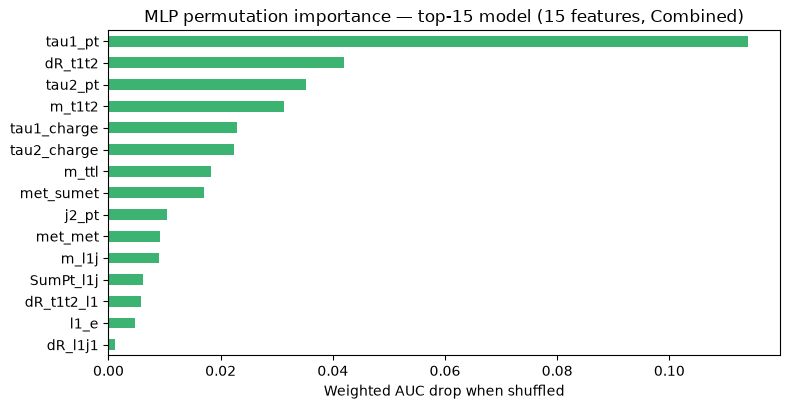


Weighted train(eval-mode)/validation AUC comparison (Combined):


,model,train_auc_eval,val_auc
0,Full (68 features),0.951418,0.946220
1,Pruned (20 features),0.944199,0.941738
2,Top-15 (15 features),0.940157,0.937487


In [ ]:
TOP15_FEATURES_comb, dropped_top15_comb = prune_correlated(top_feats_comb, corr_max_comb, CORR_THRESH, n_keep=15)

X_train_top15_t_comb, X_val_top15_t_comb, X_test_top15_t_comb = subset_feature_tensors_comb(TOP15_FEATURES_comb)

model_top15_comb, history_top15_comb, val_auc_top15_comb, train_auc_top15_comb, train_auc_eval_top15_comb = train_model(
    hidden_sizes=best_hidden_sizes_comb, verbose=False,
    X_train_data=X_train_top15_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_top15_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

importance_top15_comb = permutation_importance(model_top15_comb, X_val_top15_t_comb, y_val_t_comb, w_val_t_comb, TOP15_FEATURES_comb, n_repeats=5)
plot_importance_bar(
    importance_top15_comb, top_n=len(TOP15_FEATURES_comb),
    title=f"MLP permutation importance — top-15 model ({len(TOP15_FEATURES_comb)} features, Combined)",
    color="mediumseagreen",
)

comparison_comb = pd.DataFrame([
    {"model": f"Full ({len(features_comb)} features)", "train_auc_eval": best_train_auc_eval_comb, "val_auc": best_val_auc_comb},
    {"model": f"Pruned ({len(PRUNED_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_pruned_comb, "val_auc": val_auc_pruned_comb},
    {"model": f"Top-15 ({len(TOP15_FEATURES_comb)} features)", "train_auc_eval": train_auc_eval_top15_comb, "val_auc": val_auc_top15_comb},
]).sort_values("val_auc", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (Combined):")
comparison_comb


## Physics Figure of Merit & Final Summary — Combined

Reuses `significance_scan` from the Run 2 section, on VAL (model/cut
selection set). A genuinely blind estimate follows in the "Held-Out Test
Evaluation" cell below: the VAL-selected score cut applied FROZEN to the
Combined track's held-out TEST partition.


In [ ]:
# ---- Score the LAST PRUNED MODEL (top-15 features) - the most decorrelated/
# interpretable feature set from the Combined pruning walk above. The score
# CUT is selected here by scanning VAL only - it is applied FROZEN to test in
# the "Held-Out Test Evaluation" cell below, never re-scanned there.

models_registry_comb = {
    f"Full ({len(features_comb)} features)": (model_comb, X_val_t_comb, X_test_t_comb),
    f"Pruned ({len(PRUNED_FEATURES_comb)} features)": (model_pruned_comb, X_val_pruned_t_comb, X_test_pruned_t_comb),
    f"Top-15 ({len(TOP15_FEATURES_comb)} features)": (model_top15_comb, X_val_top15_t_comb, X_test_top15_t_comb),
}
best_name_comb = f"Top-15 ({len(TOP15_FEATURES_comb)} features)"

final_model_comb, X_val_final_t_comb, X_test_final_t_comb = models_registry_comb[best_name_comb]

final_model_comb.eval()
with torch.no_grad():
    val_scores_comb = torch.sigmoid(final_model_comb(X_val_final_t_comb)).cpu().numpy()

z_val_comb, thr_val_comb = significance_scan(y_val_comb, val_scores_comb, w_val_comb)  # signed w_phys - expected yields
final_val_auc_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "val_auc"].iloc[0]
final_train_auc_eval_comb = comparison_comb.loc[comparison_comb["model"] == best_name_comb, "train_auc_eval"].iloc[0]

print(f"Final model: {best_name_comb}")
print(f"Weighted val AUC = {final_val_auc_comb:.4f}")
print(f"Max Asimov Z (val) = {z_val_comb:.3f} at score cut = {thr_val_comb:.4f}")


Final model: Top-15 (15 features)
Weighted val AUC = 0.9375
Max Asimov Z (val) = 0.046 at score cut = 0.9875


### Held-Out Test Evaluation (Combined)

`X_test_final_t_comb`/`y_test_comb`/`w_test_comb` have not participated in
anything above. This is the one place they are read: the final model is
scored once, and the VAL-selected score cut is applied frozen.


In [ ]:
# ---- HELD-OUT TEST EVALUATION (Combined) — scored EXACTLY ONCE ------------
# X_test_final_t_comb/y_test_comb/w_test_comb have not been touched anywhere
# above - this is the only cell in the Combined section that reads them. The
# score cut `thr_val_comb` was chosen by scanning VAL only; it is applied
# here FROZEN, NOT re-scanned on test.

final_model_comb.eval()
with torch.no_grad():
    test_scores_comb = torch.sigmoid(final_model_comb(X_test_final_t_comb)).cpu().numpy()

auc_test_comb = roc_auc_score(y_test_comb, test_scores_comb, sample_weight=w_test_fit_comb)

S_test_comb = w_test_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 1)].sum()
B_test_comb = w_test_comb[(test_scores_comb >= thr_val_comb) & (y_test_comb == 0)].sum()
z_test_comb = (np.sqrt(2 * ((S_test_comb + B_test_comb) * np.log(1 + S_test_comb / B_test_comb) - S_test_comb))
               if (S_test_comb > 0 and B_test_comb > 0) else np.nan)

print(f"Final model: {best_name_comb}")
print(f"Weighted AUC: val = {final_val_auc_comb:.4f}  |  test (held-out, scored once) = {auc_test_comb:.4f}")
print(f"At the VAL-selected score cut = {thr_val_comb:.4f} (frozen, NOT re-scanned on test):")
print(f"  test S = {S_test_comb:.2f} | test B = {B_test_comb:.2f} | test Z = {z_test_comb:.3f}  (val Z was {z_val_comb:.3f})")


Final model: Top-15 (15 features)
Weighted AUC: val = 0.9375  |  test (held-out, scored once) = 0.9392
At the VAL-selected score cut = 0.9875 (frozen, NOT re-scanned on test):
  test S = 0.07 | test B = 3.47 | test Z = 0.039  (val Z was 0.046)


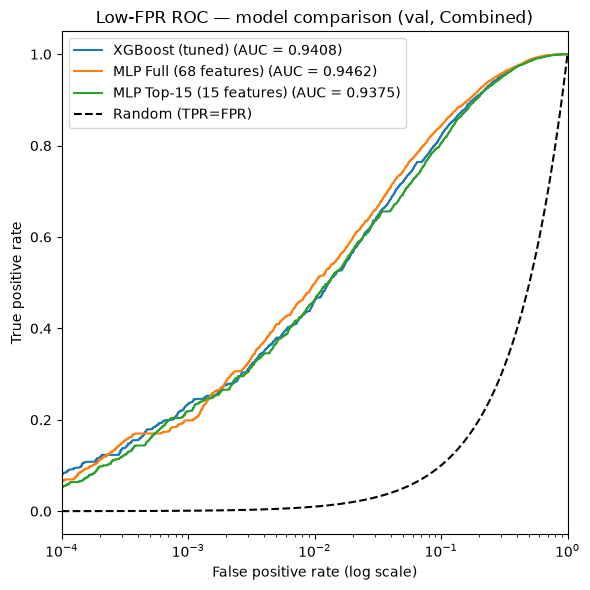

--- FPR = 1e-03 (~172 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.2346  (235x random lift)
  MLP Full (68 features)           TPR = 0.1986  (199x random lift)
  MLP Top-15 (15 features)         TPR = 0.2181  (218x random lift)
--- FPR = 1e-02 (~1722 surviving background MC events) ---
  XGBoost (tuned)                  TPR = 0.4596  (46x random lift)
  MLP Full (68 features)           TPR = 0.4985  (50x random lift)
  MLP Top-15 (15 features)         TPR = 0.4622  (46x random lift)


In [ ]:
# ---- Load the tuned XGBoost model for the Combined Run2+Run3 track, for an
# apples-to-apples overlay. val_df_comb here is the Combined track's own
# holdout split (stratified on label AND run).

import xgboost as xgb

BASE_DIR_COMB = Path("PPSSP_2026/1l2tau/combined")

xgb_model_comb = xgb.XGBClassifier()
xgb_model_comb.load_model(BASE_DIR_COMB / "final_model_combined.json")
with open(BASE_DIR_COMB / "optuna_features_combined.json") as f:
    xgb_features_comb = json.load(f)

xgb_val_scores_comb = xgb_model_comb.predict_proba(val_df_comb[xgb_features_comb])[:, 1]

# ROC curve for the FINAL model (top-15 pruned, `val_scores_comb` from the
# significance-scan cell above), not the full model - matches the `best_name_comb` label.
fpr_val_comb, tpr_val_comb, _ = roc_curve(y_val_comb, val_scores_comb, sample_weight=w_val_fit_comb)

curves_comb = {
    "XGBoost (tuned)": roc_with_auc(y_val_comb, xgb_val_scores_comb, w_val_fit_comb),
    f"MLP Full ({len(features_comb)} features)": roc_with_auc(y_val_comb, val_probs_comb, w_val_fit_comb),
    f"MLP {best_name_comb}": (fpr_val_comb, tpr_val_comb, final_val_auc_comb),
}

plt.figure(figsize=(6, 6))
for name, (fpr, tpr, auc) in curves_comb.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

x_random = np.logspace(-4, 0, 200)
plt.plot(x_random, x_random, "k--", label="Random (TPR=FPR)")

plt.xscale("log")
plt.xlim(1e-4, 1)
plt.xlabel("False positive rate (log scale)")
plt.ylabel("True positive rate")
plt.title("Low-FPR ROC — model comparison (val, Combined)")
plt.legend()
plt.tight_layout()
plt.show()

n_bkg_val_comb = int((y_val_comb == 0).sum())
for target_fpr in (1e-3, 1e-2):
    print(f"--- FPR = {target_fpr:.0e} (~{target_fpr * n_bkg_val_comb:.0f} surviving background MC events) ---")
    for name, (fpr, tpr, _) in curves_comb.items():
        idx = min(np.searchsorted(fpr, target_fpr), len(tpr) - 1)
        print(f"  {name:32s} TPR = {tpr[idx]:.4f}  ({tpr[idx] / target_fpr:.0f}x random lift)")

In [ ]:
# ---- Sanity checks --------------------------------------------------------
assert np.isfinite(X_train_scaled_comb).all() and np.isfinite(X_val_scaled_comb).all() and np.isfinite(X_test_scaled_comb).all(), \
    "NaN/inf reached the model input (Combined)"

# Determinism check, same convention as the Run 2/Run 3 sections.
set_seed(RANDOM_STATE)
_, _, det_check_a_comb, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)

set_seed(RANDOM_STATE)
_, _, det_check_b_comb, _, _ = train_model(
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
    X_train_data=X_train_t_comb, y_train_data=y_train_t_comb, w_train_data=w_train_t_comb,
    X_val_data=X_val_t_comb, y_val_data=y_val_t_comb, w_val_data=w_val_t_comb,
    w_train_eval_data=w_train_abs_t_comb,
)
assert det_check_a_comb == det_check_b_comb, f"Determinism check FAILED: {det_check_a_comb} != {det_check_b_comb}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a_comb:.6f}")

# ---- Final summary ---------------------------------------------------------
# Includes the once-only held-out test numbers computed in the
# "Held-Out Test Evaluation" cell above (auc_test_comb, z_test_comb at the
# frozen, VAL-selected score cut).

summary_comb = pd.DataFrame([{
    "model": best_name_comb,
    "train_auc_eval": final_train_auc_eval_comb,
    "val_auc": final_val_auc_comb,
    "max_asimov_Z (val)": z_val_comb,
    "test_auc (held-out, scored once)": auc_test_comb,
    "test_Z_at_val_cut (held-out)": z_test_comb,
}])

print("\nFinal summary (MLP, 1l2tau Combined Run2+Run3):")
print(summary_comb.to_string(index=False))
summary_comb


Determinism check passed: two re-seeded runs give identical val_auc = 0.928532

Final summary (MLP, 1l2tau Combined Run2+Run3):
               model  train_auc_eval  val_auc  max_asimov_Z (val)  test_auc (held-out, scored once)  test_Z_at_val_cut (held-out)
Top-15 (15 features)        0.940157 0.937487            0.046078                          0.939173                      0.039404


,model,train_auc_eval,val_auc,max_asimov_Z (val),"test_auc (held-out, scored once)",test_Z_at_val_cut (held-out)
0,Top-15 (15 features),0.940157,0.937487,0.046078,0.939173,0.039404
